# 1.0 Introduction
In this notebook, we will perform:

*   Data transformation
*   Model development
*   Explainable AI (XAI) Implementation



# 2.0 Importing the Required Libraries

In [ ]:
# Install dependencies as needed:
%pip install category_encoders
%pip install lightgbm
%pip install tensorflow
%pip install catboost
%pip install lime
%pip install shap
%pip install scikit-learn

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import category_encoders as ce
import tensorflow as tf
import shap

from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.svm import SVR
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from lightgbm.callback import early_stopping
from catboost import CatBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from lime import lime_tabular
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print("Running locally — skipping Google Colab mounting.")

   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/8.7 MB 12.1 MB/s eta 0:00:01
   --------------------- ------------------ 4.7/8.7 MB 11.9 MB/s eta 0:00:01
   ------------------------------------- -- 8.1/8.7 MB 13.6 MB/s eta 0:00:01
   ---------------------------------------- 8.7/8.7 MB 11.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.6 MB 11.5 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.6 MB 11.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 11.3 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 9.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 26.5 MB/s eta 0:00:00

  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/332.0 MB 7.4 MB/s eta 0:00:45
    --------------------------------------- 4.7/332.0 MB 15.5 MB/s eta 0:00:22
   - -------------------------------------- 8.9/332.0 MB 18.8 MB/s eta 0:00:18
   - -------------------------------------- 14.2/332.0 MB 19.9 MB/s eta 0:00:16
   - -------------------------------------- 16.0/332.0 MB 18.2 MB/s eta 0:00:18
   -- ------------------------------------- 18.9/332.0 MB 16.7 MB/s eta 0:00:19
   -- ------------------------------------- 21.0/332.0 MB 15.8 MB/s eta 0:00:20
   -- ------------------------------------- 22.8/332.0 MB 14.7 MB/s eta 0:00:22
   -- ------------


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\mingr\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\urllib3\response.py", line 438, in _error_catcher
    yield
  File "c:\Users\mingr\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\urllib3\response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "c:\Users\mingr\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\urllib3\response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "c:\Users\mingr\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\cachecontrol\filewrapper.py", line 98, in read
    data: bytes = self.__fp.read(amt)
                  ~~~~~~~~~~~~~~^^^

^C
Note: you may need to restart the kernel to use updated packages.
^C
Note: you may need to restart the kernel to use updated packages.


In [2]:
# import csv from google drive
path = '/content/drive/My Drive/FYP_Fish/1 final dataset/final_combined_fisheries_weather_dataset.csv'
df = pd.read_csv(path)
df.head()

/tmp/ipython-input-2362790949.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,species,month,state,gear_type,landings,year,temperature,pressure,dew_point,humidity,wind_speed,wind_chill,uv_index,date
0,AluAluKacangKacang,1,Kedah,Anchovy Purse Seines,0.143854,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
1,AluAluKacangKacang,1,Kedah,Bag Nets,0.005799,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
2,AluAluKacangKacang,1,Kedah,Barrier Nets,0.039637,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
3,AluAluKacangKacang,1,Kedah,Drift/Gill Nets,9.402587,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
4,AluAluKacangKacang,1,Kedah,Fish Purse Seines,1.865361,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01


# 3.0 Data Preprocessing

## 3.1 Identifying and Handling Duplicate Data

In [3]:
# Checking for duplicate rows
duplicate_rows = df.duplicated()
print("Number of duplicate rows:", duplicate_rows.sum())

# Displaying duplicate rows (optional)
# print("Duplicate rows:")
# print(df[duplicate_rows])

# Removing duplicate rows
df_cleaned = df.drop_duplicates()
print("\nDataFrame after removing duplicates:")
df_cleaned.head()

Number of duplicate rows: 0

DataFrame after removing duplicates:


,species,month,state,gear_type,landings,year,temperature,pressure,dew_point,humidity,wind_speed,wind_chill,uv_index,date
0,AluAluKacangKacang,1,Kedah,Anchovy Purse Seines,0.143854,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
1,AluAluKacangKacang,1,Kedah,Bag Nets,0.005799,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
2,AluAluKacangKacang,1,Kedah,Barrier Nets,0.039637,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
3,AluAluKacangKacang,1,Kedah,Drift/Gill Nets,9.402587,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01
4,AluAluKacangKacang,1,Kedah,Fish Purse Seines,1.865361,2011,26.61172,1007.996174,23.559405,82.419672,9.318491,26.611627,2.077531,2011-01-01


## 3.2 Identifying and Handling Missing Values

In [4]:
# Identifying missing values
print("\nMissing values per column:")
print(df_cleaned.isnull().sum())


Missing values per column:
species             0
month               0
state               0
gear_type           0
landings            0
year                0
temperature         0
pressure            0
dew_point           0
humidity            0
wind_speed          0
wind_chill          0
uv_index            0
date           397488
dtype: int64


In [5]:
# Dropping the 'date' column
if 'date' in df_cleaned.columns:
  df_cleaned = df_cleaned.drop(columns=['date'])
  print("\nDataFrame after removing 'date' column:")
  print(df_cleaned.head())
else:
  print("\n'date' column not found in the DataFrame.")


DataFrame after removing 'date' column:
              species  month  state             gear_type  landings  year  \
0  AluAluKacangKacang      1  Kedah  Anchovy Purse Seines  0.143854  2011   
1  AluAluKacangKacang      1  Kedah              Bag Nets  0.005799  2011   
2  AluAluKacangKacang      1  Kedah          Barrier Nets  0.039637  2011   
3  AluAluKacangKacang      1  Kedah       Drift/Gill Nets  9.402587  2011   
4  AluAluKacangKacang      1  Kedah     Fish Purse Seines  1.865361  2011   

   temperature     pressure  dew_point   humidity  wind_speed  wind_chill  \
0     26.61172  1007.996174  23.559405  82.419672    9.318491   26.611627   
1     26.61172  1007.996174  23.559405  82.419672    9.318491   26.611627   
2     26.61172  1007.996174  23.559405  82.419672    9.318491   26.611627   
3     26.61172  1007.996174  23.559405  82.419672    9.318491   26.611627   
4     26.61172  1007.996174  23.559405  82.419672    9.318491   26.611627   

   uv_index  
0  2.077531  
1  2.

# 4.0 Data Transformation

## 4.1 Handle Categorical Data
*   species
*   state
*   gear_type

Use Label Encoding to handle categorical data







In [6]:
print("Unique values in 'species' column:")
print(df_cleaned['species'].unique())

print("\nUnique values in 'state' column:")
print(df_cleaned['state'].unique())

print("\nUnique values in 'gear_type' column:")
print(df_cleaned['gear_type'].unique())

Unique values in 'species' column:
['AluAluKacangKacang' 'Ketamlaut' 'Bawalputih' 'Kerisibali' 'Bijinangka'
 'Kerisi' 'KayuTongkolAyahitam' 'Bawalhitam' 'GelamaTengkerong' 'Selar'
 'Sebelah' 'Tenggiri' 'Selarkuning' 'Siakap' 'Yu']

Unique values in 'state' column:
['Kedah' 'Kelantan' 'Labuan' 'Melaka' 'Negeri Sembilan' 'Pahang' 'Perak'
 'Perlis' 'Pulau Pinang' 'Sabah' 'Sarawak' 'Selangor' 'Terengganu' 'Johor']

Unique values in 'gear_type' column:
['Anchovy Purse Seines' 'Bag Nets' 'Barrier Nets' 'Drift/Gill Nets'
 'Fish Purse Seines' 'Hooks & Lines' 'Lift Nets' 'Miscellaneous'
 'Other Seines' 'Portable Traps' 'Push/Scoop Nets' 'Shellfishcollection'
 'Stationary Traps' 'Trawl Nets']


In [7]:
# print the encoding label that will be assigned

# Initialize the label encoder
encoder = ce.OrdinalEncoder(cols=['species', 'state', 'gear_type'])

# Fit and transform the data
df_encoded = encoder.fit_transform(df_cleaned)

# Print the mapping for each column
print("\nEncoding labels for 'species':")
print(encoder.category_mapping[0])

print("\nEncoding labels for 'state':")
print(encoder.category_mapping[1])

print("\nEncoding labels for 'gear_type':")
encoder.category_mapping[2]


Encoding labels for 'species':
{'col': 'species', 'mapping': AluAluKacangKacang      1
Ketamlaut               2
Bawalputih              3
Kerisibali              4
Bijinangka              5
Kerisi                  6
KayuTongkolAyahitam     7
Bawalhitam              8
GelamaTengkerong        9
Selar                  10
Sebelah                11
Tenggiri               12
Selarkuning            13
Siakap                 14
Yu                     15
NaN                    -2
dtype: int64, 'data_type': dtype('O')}

Encoding labels for 'state':
{'col': 'state', 'mapping': Kedah               1
Kelantan            2
Labuan              3
Melaka              4
Negeri Sembilan     5
Pahang              6
Perak               7
Perlis              8
Pulau Pinang        9
Sabah              10
Sarawak            11
Selangor           12
Terengganu         13
Johor              14
NaN                -2
dtype: int64, 'data_type': dtype('O')}

Encoding labels for 'gear_type':


{'col': 'gear_type',
 'mapping': Anchovy Purse Seines     1
 Bag Nets                 2
 Barrier Nets             3
 Drift/Gill Nets          4
 Fish Purse Seines        5
 Hooks & Lines            6
 Lift Nets                7
 Miscellaneous            8
 Other Seines             9
 Portable Traps          10
 Push/Scoop Nets         11
 Shellfishcollection     12
 Stationary Traps        13
 Trawl Nets              14
 NaN                     -2
 dtype: int64,
 'data_type': dtype('O')}

In [8]:
# Perform the encoding on the DataFrame
df_encoded = encoder.transform(df_cleaned)

print("\nDataFrame after label encoding:")
print(df_encoded.head())


DataFrame after label encoding:
   species  month  state  gear_type  landings  year  temperature     pressure  \
0        1      1      1          1  0.143854  2011     26.61172  1007.996174   
1        1      1      1          2  0.005799  2011     26.61172  1007.996174   
2        1      1      1          3  0.039637  2011     26.61172  1007.996174   
3        1      1      1          4  9.402587  2011     26.61172  1007.996174   
4        1      1      1          5  1.865361  2011     26.61172  1007.996174   

   dew_point   humidity  wind_speed  wind_chill  uv_index  
0  23.559405  82.419672    9.318491   26.611627  2.077531  
1  23.559405  82.419672    9.318491   26.611627  2.077531  
2  23.559405  82.419672    9.318491   26.611627  2.077531  
3  23.559405  82.419672    9.318491   26.611627  2.077531  
4  23.559405  82.419672    9.318491   26.611627  2.077531  


## 4.2 Hanlde Numerical Data

*   temperature
*   pressure
*   dew_point
*   humidity
*   wind_speed
*   wind_chill
*   uv_index
*   landings
*   month
*   year

Use normalization to handle numerical data



In [9]:
# Identifying numerical columns
numerical_cols = [
    'temperature',
    'pressure',
    'dew_point',
    'humidity',
    'wind_speed',
    'wind_chill',
    'uv_index',
    'landings',
]

# Check if all numerical columns exist in the DataFrame
existing_numerical_cols = [col for col in numerical_cols if col in df_encoded.columns]
if len(existing_numerical_cols) != len(numerical_cols):
    print("Warning: Some specified numerical columns do not exist in the DataFrame.")
    print("Columns not found:", set(numerical_cols) - set(existing_numerical_cols))

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply Min-Max Normalization to the existing numerical columns
df_encoded[existing_numerical_cols] = scaler.fit_transform(df_encoded[existing_numerical_cols])

print("\nDataFrame after Normalization:")
print(df_encoded.head())


DataFrame after Normalization:
   species  month  state  gear_type  landings  year  temperature  pressure  \
0        1      1      1          1  0.000116  2011     0.007591   0.36877   
1        1      1      1          2  0.000005  2011     0.007591   0.36877   
2        1      1      1          3  0.000032  2011     0.007591   0.36877   
3        1      1      1          4  0.007613  2011     0.007591   0.36877   
4        1      1      1          5  0.001510  2011     0.007591   0.36877   

   dew_point  humidity  wind_speed  wind_chill  uv_index  
0   0.077113   0.48461     0.81154    0.007422  0.311406  
1   0.077113   0.48461     0.81154    0.007422  0.311406  
2   0.077113   0.48461     0.81154    0.007422  0.311406  
3   0.077113   0.48461     0.81154    0.007422  0.311406  
4   0.077113   0.48461     0.81154    0.007422  0.311406  


# 5.0 Fixing Multicollinearity

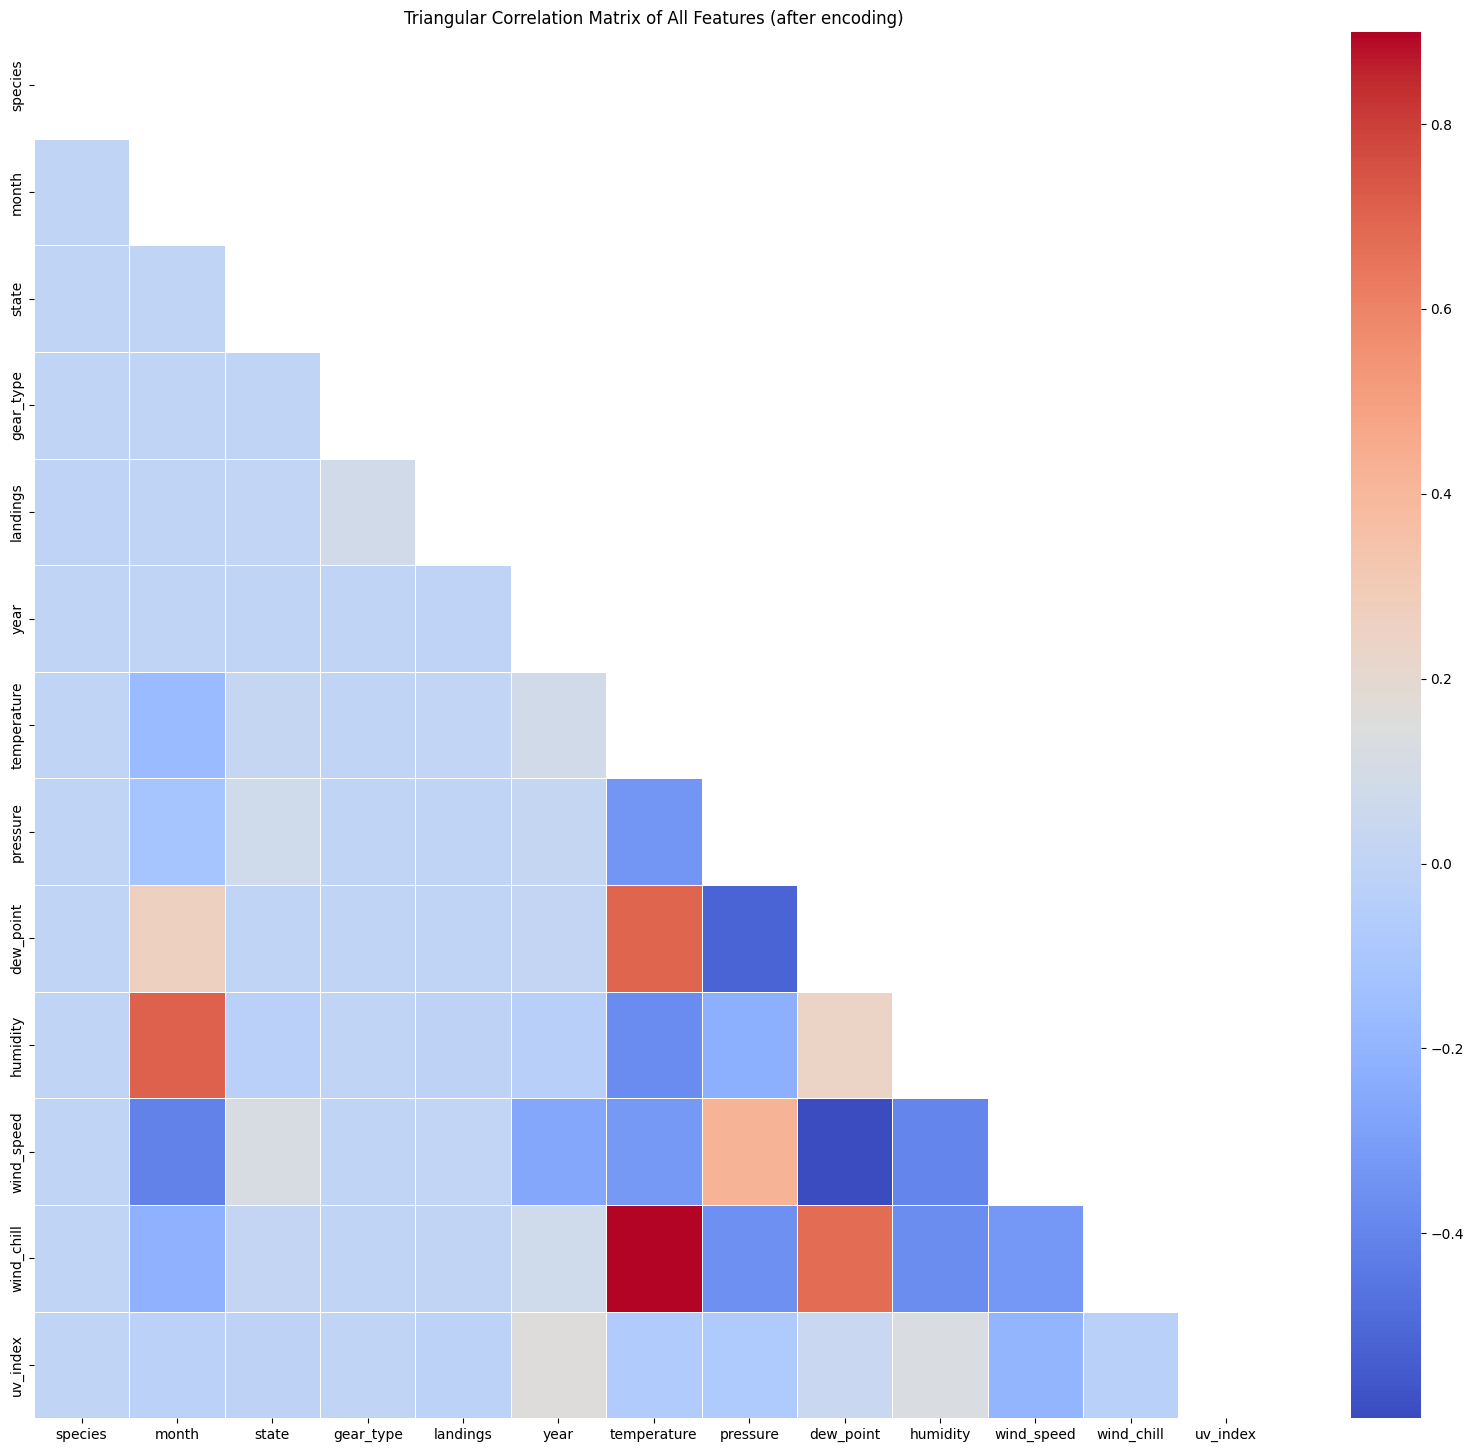

In [10]:
# create a correlation matrix

# Select only the numerical features
numerical_features = df_encoded.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix_encoded = numerical_features.corr()

# Create a mask to show only the lower triangle
mask_encoded = np.triu(np.ones_like(correlation_matrix_encoded, dtype=bool))

# Plot the triangular correlation matrix for the encoded DataFrame
plt.figure(figsize=(20, 18)) # Adjust figure size as needed
sns.heatmap(correlation_matrix_encoded, mask=mask_encoded, annot=False, fmt=".2f", cmap='coolwarm', linewidths=.5) # annot=False for many features
plt.title('Triangular Correlation Matrix of All Features (after encoding)')
plt.show()

In [11]:
# Set the correlation threshold
threshold = 0.75

# Dictionary to store highly correlated feature pairs
high_correlation_pairs = {}

# Loop through the correlation matrix
for i in range(len(correlation_matrix_encoded.columns)):
    for j in range(i + 1, len(correlation_matrix_encoded.columns)):
        col1 = correlation_matrix_encoded.columns[i]
        col2 = correlation_matrix_encoded.columns[j]
        correlation_value = correlation_matrix_encoded.iloc[i, j]

        # Check if correlation is strongly positive or negative
        if correlation_value > threshold or correlation_value < -threshold:
            high_correlation_pairs[(col1, col2)] = correlation_value

# Print results
print(f"\nFeatures with high positive or negative correlation (>|{threshold}|):")
if high_correlation_pairs:
    for (col1, col2), correlation_value in high_correlation_pairs.items():
        print(f"  - {col1} and {col2}: {correlation_value:.2f}")
else:
    print("  No highly correlated feature pairs found.")



Features with high positive or negative correlation (>|0.75|):
  - temperature and wind_chill: 0.90


Remove wind_chill column

In [12]:
# Dropping the 'wind_chill' column if it exists
if 'wind_chill' in df_encoded.columns:
  df_encoded = df_encoded.drop(columns=['wind_chill'])
  print("\nDataFrame after removing 'wind_chill' column:")
  print(df_encoded.head())
else:
  print("\n'wind_chill' column not found in the DataFrame.")


DataFrame after removing 'wind_chill' column:
   species  month  state  gear_type  landings  year  temperature  pressure  \
0        1      1      1          1  0.000116  2011     0.007591   0.36877   
1        1      1      1          2  0.000005  2011     0.007591   0.36877   
2        1      1      1          3  0.000032  2011     0.007591   0.36877   
3        1      1      1          4  0.007613  2011     0.007591   0.36877   
4        1      1      1          5  0.001510  2011     0.007591   0.36877   

   dew_point  humidity  wind_speed  uv_index  
0   0.077113   0.48461     0.81154  0.311406  
1   0.077113   0.48461     0.81154  0.311406  
2   0.077113   0.48461     0.81154  0.311406  
3   0.077113   0.48461     0.81154  0.311406  
4   0.077113   0.48461     0.81154  0.311406  


# 6.0 Data Splitting

In [13]:
# split data into training set (2011 - 2019), validation set (2020) , testing set (2021 - 2023)
print('Size of the dataset before splitting: ', df_encoded.shape)

# Ensure 'year' is treated as an integer or object for filtering
df_encoded['year'] = df_encoded['year'].astype(int)

# Split data based on year
train_df = df_encoded[(df_encoded['year'] >= 2011) & (df_encoded['year'] <= 2019)]
val_df = df_encoded[df_encoded['year'] == 2020]
test_df = df_encoded[(df_encoded['year'] >= 2021) & (df_encoded['year'] <= 2023)]

print(f"Training set shape: {train_df.shape}")
print(f"Validation set shape: {val_df.shape}")
print(f"Testing set shape: {test_df.shape}")

Size of the dataset before splitting:  (458640, 12)
Training set shape: (317520, 12)
Validation set shape: (35280, 12)
Testing set shape: (105840, 12)


In [14]:
# Further split into train_x, train_y, validate_x, validate_y, test_x, test_y

# Define the target variable (y) and features (x)
target = 'landings'
features = [col for col in df_encoded.columns if col != target]

# Split each set into features (x) and target (y)
train_x = train_df[features]
train_y = train_df[target]

val_x = val_df[features]
val_y = val_df[target]

test_x = test_df[features]
test_y = test_df[target]

print("\nShapes after splitting into x and y:")
print(f"train_x shape: {train_x.shape}")
print(f"train_y shape: {train_y.shape}")
print(f"validate_x shape: {val_x.shape}")
print(f"validate_y shape: {val_y.shape}")
print(f"test_x shape: {test_x.shape}")
print(f"test_y shape: {test_y.shape}")


Shapes after splitting into x and y:
train_x shape: (317520, 11)
train_y shape: (317520,)
validate_x shape: (35280, 11)
validate_y shape: (35280,)
test_x shape: (105840, 11)
test_y shape: (105840,)


# 7.0 Model Development

Evaluation metrics:
*   R2-Score (R2)
*   Residual Sum of Squares (RSS)
*   Mean Squared Error (MSE)
*   Root Mean Squared Error (RMSE)
*   Mean Absolute Error (MAE)





In [15]:
# === Initialize Evaluation Matrix (Only once, outside function) ===
Model_Evaluation_Comparison_Matrix = pd.DataFrame(
    np.zeros([5, 30]),
    columns=[
        'Train-R2', 'Val-R2', 'Test-R2',
        'Train-RSS', 'Val-RSS', 'Test-RSS',
        'Train-MSE', 'Val-MSE', 'Test-MSE',
        'Train-RMSE', 'Val-RMSE', 'Test-RMSE',
        'Train-MAE', 'Val-MAE', 'Test-MAE',
        'Train-Samples', 'Val-Samples', 'Test-Samples',
        'Train-MaxError', 'Val-MaxError', 'Test-MaxError',
        'Train-MinError', 'Val-MinError', 'Test-MinError',
        'Train-MedAE', 'Val-MedAE', 'Test-MedAE',
        'Train-StdError', 'Val-StdError', 'Test-StdError'
    ]
)


In [16]:
# === Evaluation Function ===
def Evaluate(n, pred_train, pred_val, pred_test,
             Train_X_std, Train_Y, Val_Y, Test_Y):

    def compute_metrics(y_true, y_pred):
        return {
            "R2": r2_score(y_true, y_pred),
            "RSS": np.sum((y_true - y_pred) ** 2),
            "MSE": mean_squared_error(y_true, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
            "MAE": mean_absolute_error(y_true, y_pred),
            "Samples": len(y_true),
            "MaxError": np.max(np.abs(y_true - y_pred)),
            "MinError": np.min(np.abs(y_true - y_pred)),
            "MedAE": np.median(np.abs(y_true - y_pred)),
            "StdError": np.std(np.abs(y_true - y_pred))
        }

    metrics_train = compute_metrics(Train_Y, pred_train)
    metrics_val   = compute_metrics(Val_Y, pred_val)
    metrics_test  = compute_metrics(Test_Y, pred_test)

    print(f"\n{'-'*10} Training Metrics {'-'*10}")
    print(metrics_train)
    print(f"\n{'-'*10} Validation Metrics {'-'*10}")
    print(metrics_val)
    print(f"\n{'-'*10} Testing Metrics {'-'*10}")
    print(metrics_test)

    # Fill evaluation matrix
    for i, key in enumerate(metrics_train.keys()):
        Model_Evaluation_Comparison_Matrix.iloc[n, i] = metrics_train[key]
        Model_Evaluation_Comparison_Matrix.iloc[n, i + 1*len(metrics_train)] = metrics_val[key]
        Model_Evaluation_Comparison_Matrix.iloc[n, i + 2*len(metrics_train)] = metrics_test[key]

    # Residual histogram
    plt.figure(figsize=[15, 5])
    sns.histplot((Train_Y - pred_train), kde=True, label='Train Errors', color='blue', alpha=0.5)
    sns.histplot((Val_Y - pred_val), kde=True, label='Validation Errors', color='green', alpha=0.5)
    sns.histplot((Test_Y - pred_test), kde=True, label='Test Errors', color='orange', alpha=0.5)
    plt.title('Residual Distribution')
    plt.xlabel('Residuals')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Actual vs Predicted plot
    plt.figure(figsize=[7, 5])
    plt.scatter(Test_Y, pred_test, alpha=0.5)
    plt.plot([Test_Y.min(), Test_Y.max()], [Test_Y.min(), Test_Y.max()], 'r--')
    plt.title('Test Set: Actual vs Predicted')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()

    # Absolute error over sample index
    plt.figure(figsize=[10, 4])
    plt.plot(np.abs(Test_Y.values - pred_test), label='Test Absolute Error')
    plt.title('Test Set Prediction Error (Loss Plot)')
    plt.xlabel('Sample Index')
    plt.ylabel('Absolute Error')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 7.1 Multiple Linear Regression

<<<----------------------------------- Evaluating Multiple Linear Regression Model ----------------------------------->>>

Coefficients:
 [-2.13510874e-05  1.18719304e-04  1.06776675e-04  6.23750469e-04
 -6.12907859e-05  1.21149279e-03 -8.92006907e-04 -4.30464926e-04
 -1.73092016e-03  1.19062562e-03 -2.02131235e-03]
Intercept:
 0.12427254168332373

---------- Training Metrics ----------
{'R2': 0.008461190106625716, 'RSS': np.float64(263.08391432929847), 'MSE': 0.0008285585611277982, 'RMSE': np.float64(0.02878469317411249), 'MAE': 0.008955899306523707, 'Samples': 317520, 'MaxError': 0.9959550161005152, 'MinError': 1.3613846286180883e-08, 'MedAE': np.float64(0.005502298287362607), 'StdError': 0.02735599438403219}

---------- Validation Metrics ----------
{'R2': 0.005743738397709808, 'RSS': np.float64(27.921698852398034), 'MSE': 0.0007914313733672912, 'RMSE': np.float64(0.028132390111174188), 'MAE': 0.008185702915517899, 'Samples': 35280, 'MaxError': 0.8779430157605151, 'MinError': 2.7673

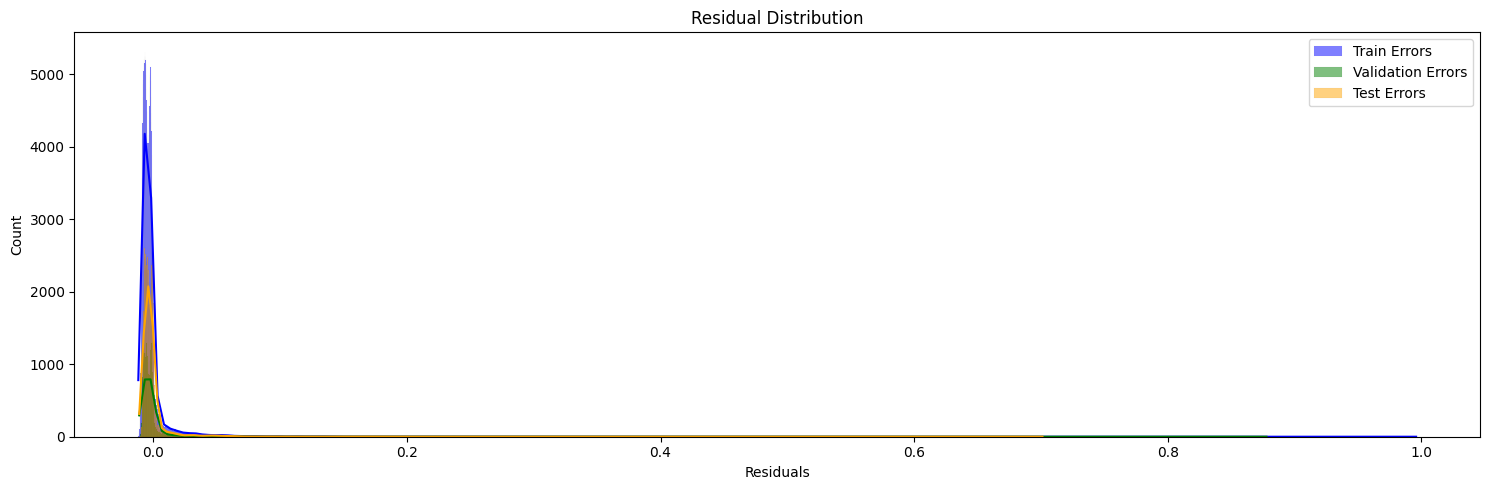

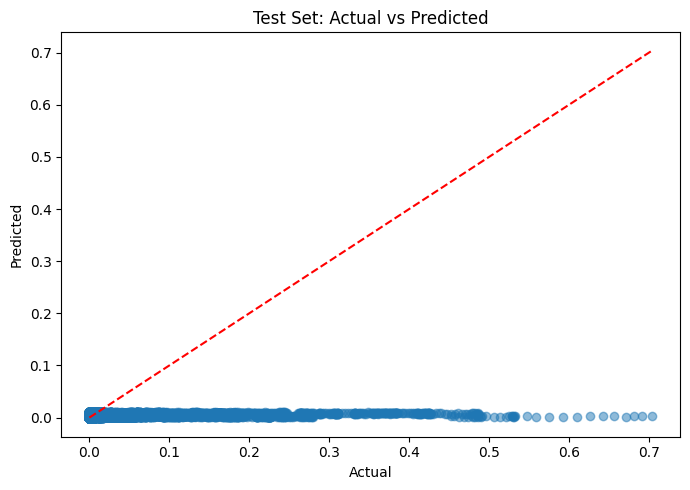

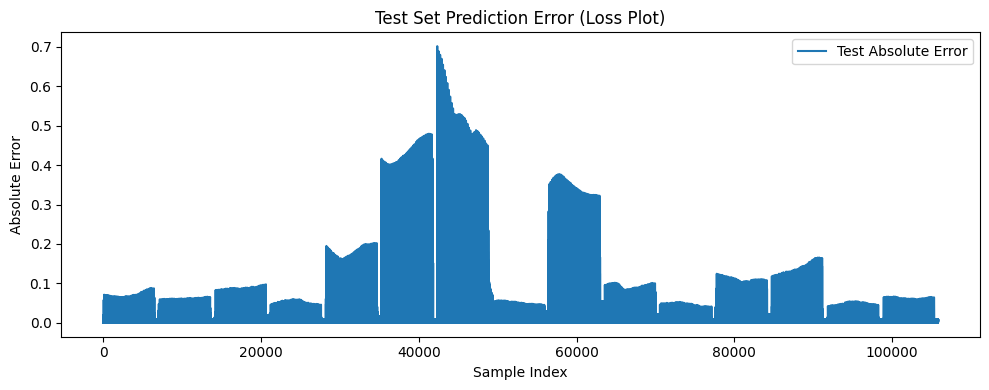

In [17]:
# === Train Linear Regression Model ===
MLR = LinearRegression()
MLR.fit(train_x, train_y)

# === Predict ===
pred_train = MLR.predict(train_x)
pred_val   = MLR.predict(val_x)
pred_test  = MLR.predict(test_x)

# === Print Coefficients ===
print(f"{'<'*3}{'-'*35} \033[1mEvaluating Multiple Linear Regression Model\033[0m {'-'*35}{'>'*3}\n")
print("Coefficients:\n", MLR.coef_)
print("Intercept:\n", MLR.intercept_)

# === Evaluate the Model ===
Evaluate(
    n=0,
    pred_train=pred_train,
    pred_val=pred_val,
    pred_test=pred_test,
    Train_X_std=train_x,
    Train_Y=train_y,
    Val_Y=val_y,
    Test_Y=test_y
)

## 7.2 Random Forest Regressor

In [18]:
# # === Train Random Forest Regressor ===
# RFR = RandomForestRegressor(
#     n_estimators=100,  # you can tune this
#     random_state=42,   # for reproducibility
#     n_jobs=-1          # utilize all processors
# )
# RFR.fit(train_x, train_y)

# # === Predict ===
# pred_train = RFR.predict(train_x)
# pred_val   = RFR.predict(val_x)
# pred_test  = RFR.predict(test_x)

# # === Print Model Summary ===
# print(f"{'<'*3}{'-'*35} \033[1mEvaluating Random Forest Regressor\033[0m {'-'*35}{'>'*3}\n")
# print("Feature Importances:\n", RFR.feature_importances_)
# print("\nNumber of Trees:", len(RFR.estimators_))

# # === Evaluate the Model ===
# Evaluate(
#     n=1,
#     pred_train=pred_train,
#     pred_val=pred_val,
#     pred_test=pred_test,
#     Train_X_std=train_x,
#     Train_Y=train_y,
#     Val_Y=val_y,
#     Test_Y=test_y
# )

## 7.3 Gradient Boosting Regressor (XGBoost)

<<<----------------------------------- Evaluating XGBoost Regressor ----------------------------------->>>

Feature Importances:
 [0.3133627  0.00556148 0.25030595 0.30366892 0.0413459  0.01076867
 0.01066422 0.01717051 0.01076475 0.01781624 0.01857068]

Number of Trees: 100

---------- Training Metrics ----------
{'R2': 0.7237592278304267, 'RSS': np.float64(73.2946637232832), 'MSE': 0.0002308347937871101, 'RMSE': np.float64(0.015193248296105416), 'MAE': 0.004584012705749087, 'Samples': 317520, 'MaxError': 0.7374969720840454, 'MinError': 8.030894525541817e-10, 'MedAE': np.float64(0.0012411884291326954), 'StdError': 0.014485220788812361}

---------- Validation Metrics ----------
{'R2': 0.6739987298257684, 'RSS': np.float64(9.155093754838443), 'MSE': 0.000259498122302677, 'RMSE': np.float64(0.016108945412492928), 'MAE': 0.004636419120843269, 'Samples': 35280, 'MaxError': 0.6244432684898977, 'MinError': 5.962421231167175e-08, 'MedAE': np.float64(0.001268470800413657), 'StdError': 0.015427

/tmp/ipython-input-2696247802.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


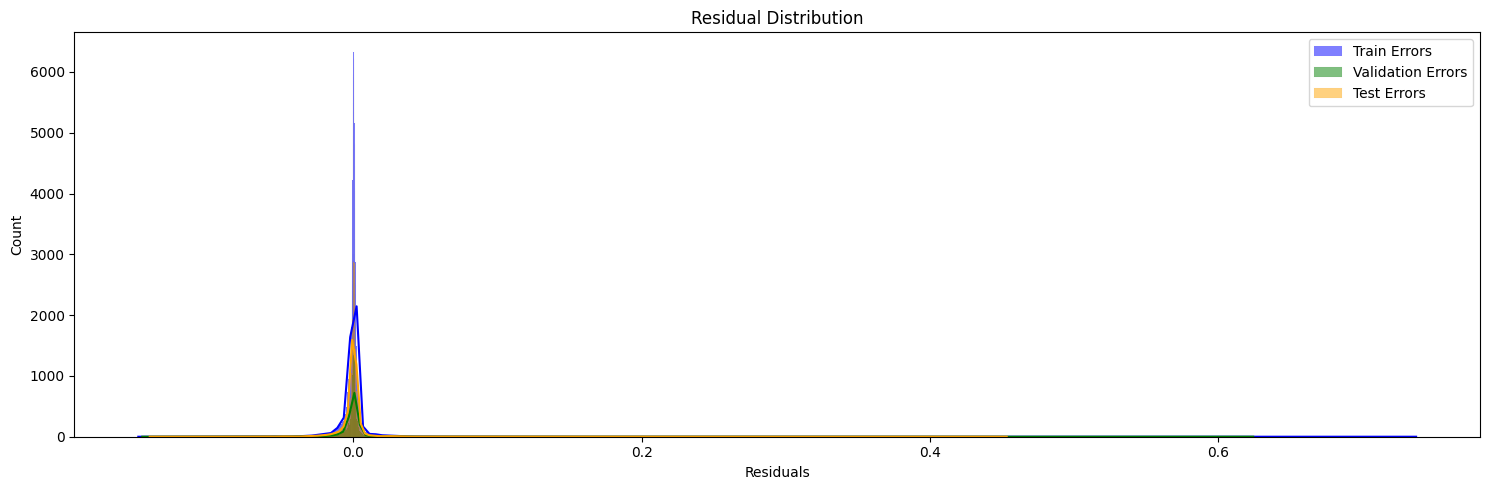

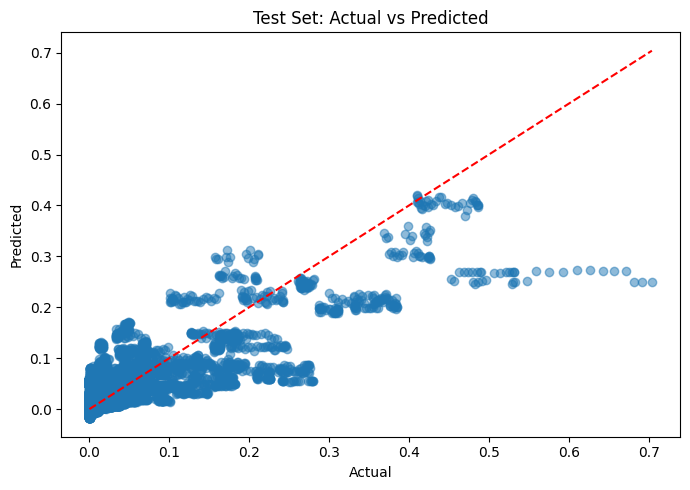

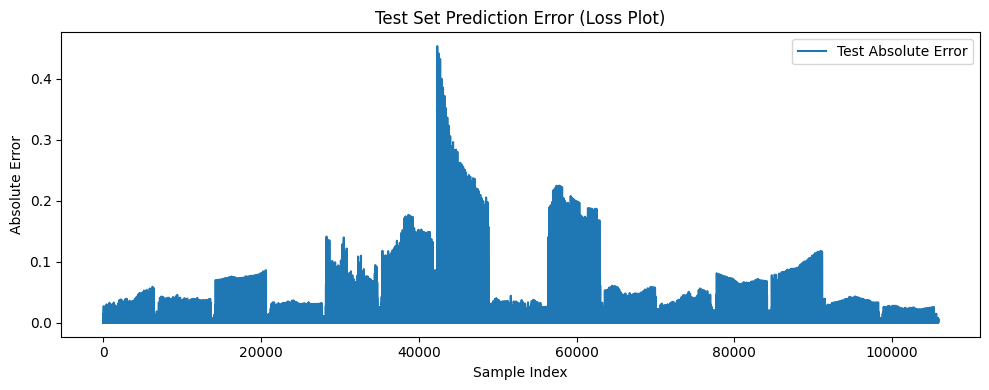

In [19]:
# === Train XGBoost Regressor ===
XGBR = XGBRegressor(
    n_estimators=100,      # number of boosting rounds
    learning_rate=0.1,     # step size shrinkage
    max_depth=6,           # maximum tree depth
    subsample=0.8,         # row sampling
    colsample_bytree=0.8,  # feature sampling
    random_state=42,
    n_jobs=-1              # parallel processing
)

evals_result = {}  # dictionary to store eval results

XGBR.fit(
    train_x, train_y,
    eval_set=[(train_x, train_y), (val_x, val_y)],
    verbose=False,
)

# === Predict ===
pred_train = XGBR.predict(train_x)
pred_val   = XGBR.predict(val_x)
pred_test  = XGBR.predict(test_x)

# === Print Model Summary ===
print(f"{'<'*3}{'-'*35} \033[1mEvaluating XGBoost Regressor\033[0m {'-'*35}{'>'*3}\n")
print("Feature Importances:\n", XGBR.feature_importances_)
print("\nNumber of Trees:", XGBR.n_estimators)

# === Evaluate the Model ===
Evaluate(
    n=1,  # Assuming this is the 2nd model (0-indexed) - Linear Regression was n=0
    pred_train=pred_train,
    pred_val=pred_val,
    pred_test=pred_test,
    Train_X_std=train_x,
    Train_Y=train_y,
    Val_Y=val_y,
    Test_Y=test_y
)

## 7.4 Gradient Boosting Regressor (LightGBM)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.059277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1597
[LightGBM] [Info] Number of data points in the train set: 317520, number of used features: 11
[LightGBM] [Info] Start training from score 0.005538
<<<----------------------------------- Evaluating LightGBM Regressor ----------------------------------->>>

Feature Importances:
 [837   4 850 573 305  23  37  71  38 138  94]

Number of Trees: 99

---------- Training Metrics ----------
{'R2': 0.8776939157438048, 'RSS': np.float64(32.4513403523448), 'MSE': 0.00010220250803837491, 'RMSE': np.float64(0.010109525608967758), 'MAE': 0.003514923746476085, 'Samples': 317520, 'MaxError': 0.3745487998484174, 'MinError': 4.32826537807786e-10, 'MedAE': np.float64(0.0007718019872322698), 'StdError': 0.009478808949168345}

---------- Validation Metrics ----------
{'R2': 0.8704991929511496, 'RSS': np.float64(3.6

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


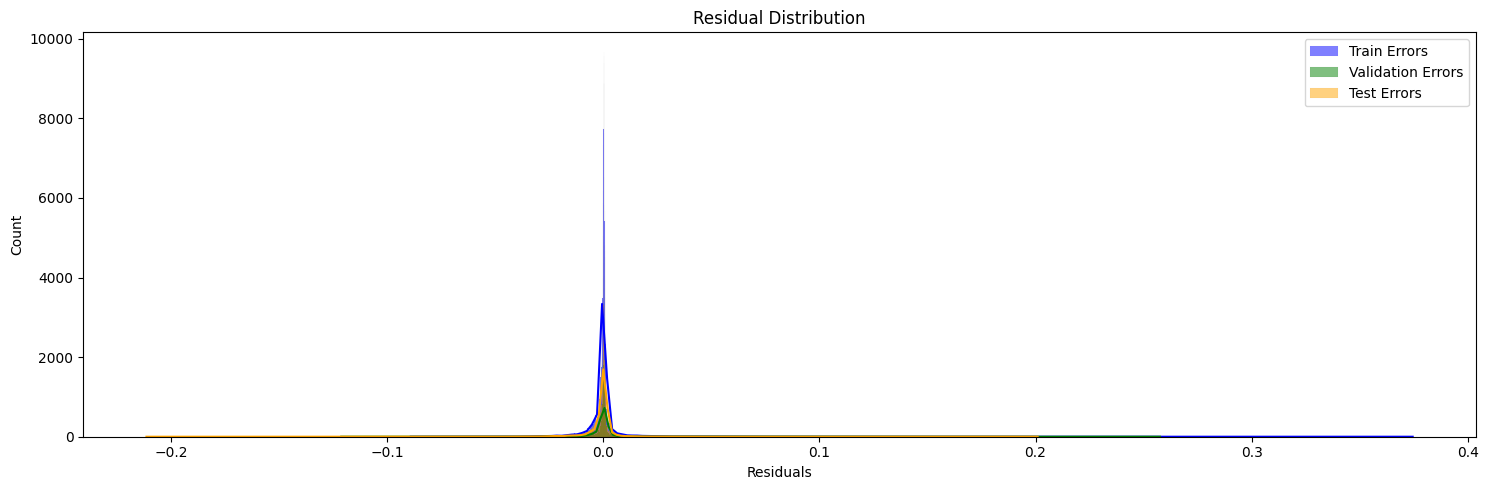

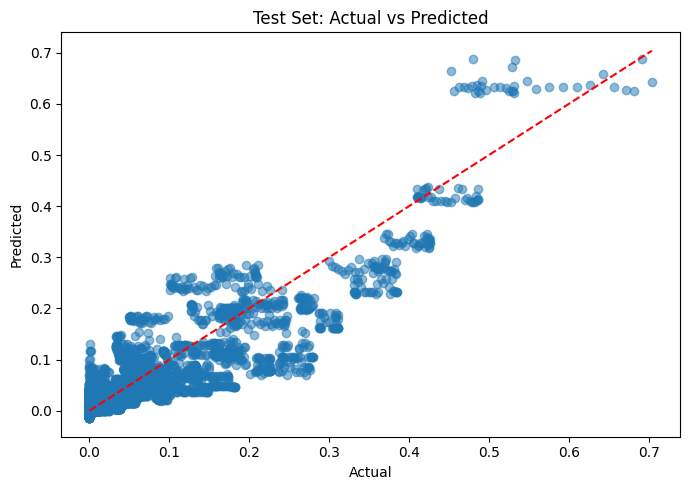

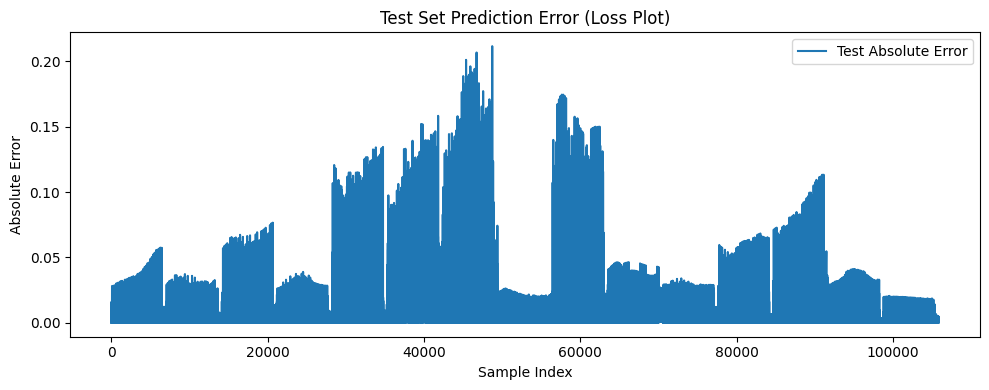

In [20]:
# === Train LightGBM Regressor ===
LGBMR = LGBMRegressor(
    n_estimators=100,      # number of boosting rounds
    learning_rate=0.1,     # step size shrinkage
    max_depth=-1,          # maximum tree depth (-1 means no limit)
    subsample=0.8,         # row sampling
    colsample_bytree=0.8,  # feature sampling
    random_state=42,
    n_jobs=-1              # parallel processing
)
LGBMR.fit(train_x, train_y, eval_set=[(val_x, val_y)], callbacks=[early_stopping(stopping_rounds=10, verbose=False)])

# === Predict ===
pred_train = LGBMR.predict(train_x)
pred_val   = LGBMR.predict(val_x)
pred_test  = LGBMR.predict(test_x)

# === Print Model Summary ===
print(f"{'<'*3}{'-'*35} \033[1mEvaluating LightGBM Regressor\033[0m {'-'*35}{'>'*3}\n")
print("Feature Importances:\n", LGBMR.feature_importances_)
print("\nNumber of Trees:", LGBMR.n_estimators_)

# === Evaluate the Model ===
Evaluate(
    n=2,  # Assuming this is the 4th model (0-indexed)
    pred_train=pred_train,
    pred_val=pred_val,
    pred_test=pred_test,
    Train_X_std=train_x,
    Train_Y=train_y,
    Val_Y=val_y,
    Test_Y=test_y
)

In [21]:
# # visualize training loss curve, validation loss curve
# # Retrieve evaluation results from the training history
# evals_result = LGBMR.get_evals_result()

# # Extract loss values (RMSE in this case)
# epochs = range(len(evals_result['learn']['RMSE']))
# train_loss = evals_result['learn']['RMSE']
# val_loss = evals_result['validation']['RMSE']

# # Plotting the loss curves
# plt.figure(figsize=(10, 6))
# plt.plot(epochs, train_loss, label='Training Loss (RMSE)')
# plt.plot(epochs, val_loss, label='Validation Loss (RMSE)')
# plt.title('CatBoost Training and Validation Loss')
# plt.xlabel('Iteration')
# plt.ylabel('RMSE')
# plt.legend()
# plt.grid(True)
# plt.show()

## 7.5 Gradient Boosting Regressor (CatBoost)

<<<----------------------------------- Evaluating CatBoost Regressor ----------------------------------->>>

Feature Importances:
      Feature Id  Importances
0       species    38.775227
1     gear_type    36.697573
2         state    23.893484
3          year     0.551178
4    wind_speed     0.074854
5      uv_index     0.006680
6     dew_point     0.000755
7      pressure     0.000250
8         month     0.000000
9   temperature     0.000000
10     humidity     0.000000

Number of Trees: 100

---------- Training Metrics ----------
{'R2': 0.6454721538572978, 'RSS': np.float64(94.06648793907246), 'MSE': 0.00029625374130471294, 'RMSE': np.float64(0.01721202316128795), 'MAE': 0.004987048753516996, 'Samples': 317520, 'MaxError': 0.8159240986722877, 'MinError': 1.6341624619778627e-09, 'MedAE': np.float64(0.0011847207125432217), 'StdError': 0.016473708933775543}

---------- Validation Metrics ----------
{'R2': 0.5969792764136022, 'RSS': np.float64(11.318031084984248), 'MSE': 0.00032080586

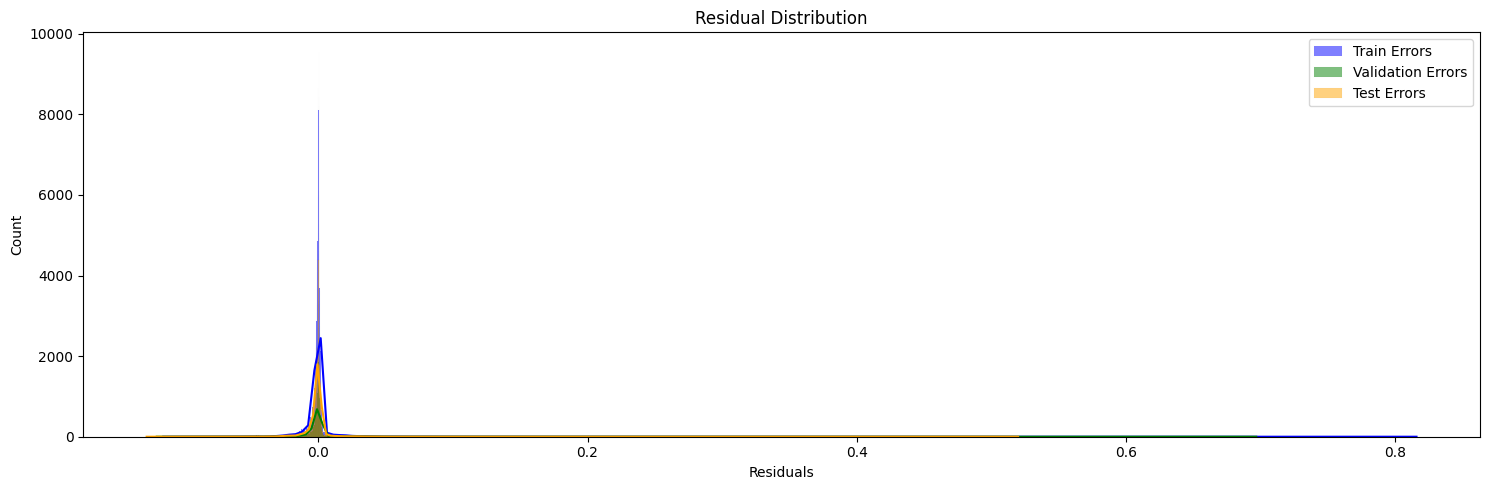

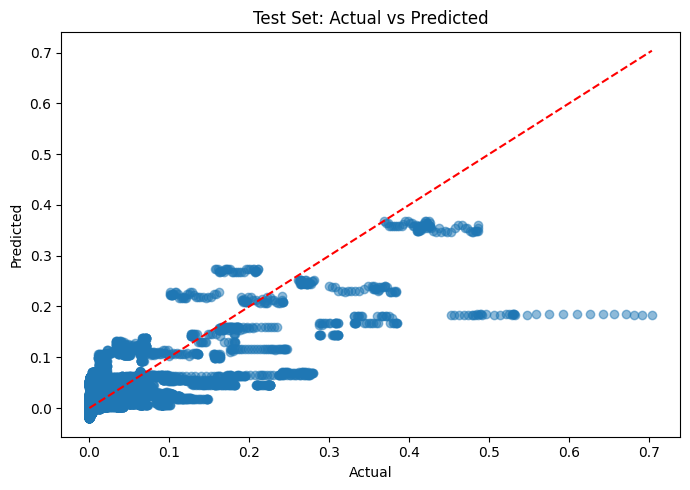

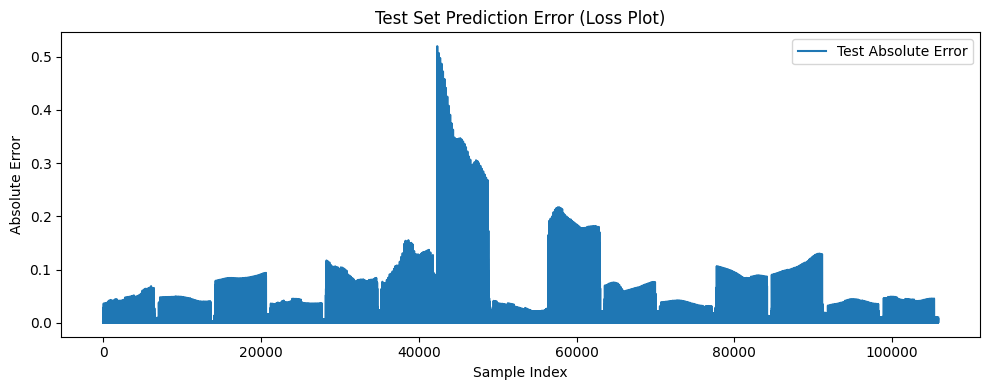

In [22]:
# === Train CatBoost Regressor ===
CBR = CatBoostRegressor(
    iterations=100,       # number of boosting rounds
    learning_rate=0.1,    # step size shrinkage
    depth=6,              # maximum tree depth
    l2_leaf_reg=3,        # L2 regularization
    loss_function='RMSE', # loss function to optimize
    eval_metric='RMSE',   # metric for evaluation
    random_state=42,
    verbose=False         # suppress verbose output during training
)

CBR.fit(train_x, train_y, eval_set=[(val_x, val_y)])

# === Predict ===
pred_train = CBR.predict(train_x)
pred_val   = CBR.predict(val_x)
pred_test  = CBR.predict(test_x)

# === Print Model Summary ===
print(f"{'<'*3}{'-'*35} \033[1mEvaluating CatBoost Regressor\033[0m {'-'*35}{'>'*3}\n")
# CatBoost feature importances
print("Feature Importances:\n", CBR.get_feature_importance(prettified=True))
print("\nNumber of Trees:", CBR.get_params()['iterations']) # Use get_params to access iterations

# === Evaluate the Model ===
Evaluate(
    n=3,  # Assuming this is the 5th model (0-indexed)
    pred_train=pred_train,
    pred_val=pred_val,
    pred_test=pred_test,
    Train_X_std=train_x, # Note: this name might be confusing as data is normalized, not standardized
    Train_Y=train_y,
    Val_Y=val_y,
    Test_Y=test_y
)

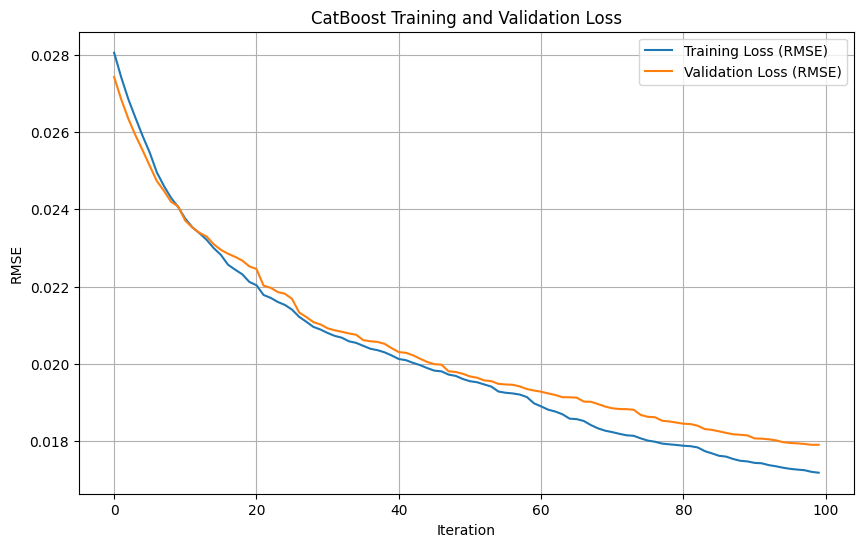

In [23]:
# visualize training loss curve, validation loss curve
# Retrieve evaluation results from the training history
evals_result = CBR.get_evals_result()

# Extract loss values (RMSE in this case)
epochs = range(len(evals_result['learn']['RMSE']))
train_loss = evals_result['learn']['RMSE']
val_loss = evals_result['validation']['RMSE']

# Plotting the loss curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Training Loss (RMSE)')
plt.plot(epochs, val_loss, label='Validation Loss (RMSE)')
plt.title('CatBoost Training and Validation Loss')
plt.xlabel('Iteration')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True)
plt.show()

## 7.6 Support Vector Regressor (SVR)

In [24]:
# # === Train SVR ===
# SVR_model = SVR(kernel='rbf') # Using Radial Basis Function kernel

# # Fit the model
# SVR_model.fit(train_x, train_y)

# # === Predict ===
# pred_train = SVR_model.predict(train_x)
# pred_val   = SVR_model.predict(val_x)
# pred_test  = SVR_model.predict(test_x)

# # === Print Model Summary ===
# print(f"{'<'*3}{'-'*35} \033[1mEvaluating Support Vector Regressor\033[0m {'-'*35}{'>'*3}\n")
# # SVR does not have feature_importances_ or n_estimators_ attributes like tree-based models
# print("SVR model trained successfully.")

# # === Evaluate the Model ===
# Evaluate(
#     n=3,  # Assuming this is the 5th model (0-indexed)
#     pred_train=pred_train,
#     pred_val=pred_val,
#     pred_test=pred_test,
#     Train_X_std=train_x,
#     Train_Y=train_y,
#     Val_Y=val_y,
#     Test_Y=test_y
# )

## 7.7 Long Short-Term Memory (LSTM)

In [25]:
# # Check if columns are numeric
# train_x = train_x.select_dtypes(include=np.number)
# val_x = val_x.select_dtypes(include=np.number)
# test_x = test_x.select_dtypes(include=np.number)

# # Ensure shapes are consistent after selecting numerical columns
# print("Shapes before reshaping for LSTM:")
# print(f"train_x shape: {train_x.shape}")
# print(f"val_x shape: {val_x.shape}")
# print(f"test_x shape: {test_x.shape}")

# train_x_lstm = train_x.values.reshape((train_x.shape[0], 1, train_x.shape[1]))
# val_x_lstm = val_x.values.reshape((val_x.shape[0], 1, val_x.shape[1]))
# test_x_lstm = test_x.values.reshape((test_x.shape[0], 1, test_x.shape[1]))

# print("\nShapes after reshaping for LSTM:")
# print(f"train_x_lstm shape: {train_x_lstm.shape}")
# print(f"val_x_lstm shape: {val_x_lstm.shape}")
# print(f"test_x_lstm shape: {test_x_lstm.shape}")


# # === Build LSTM Model ===
# LSTM_model = Sequential()
# LSTM_model.add(LSTM(50, return_sequences=False, input_shape=(train_x_lstm.shape[1], train_x_lstm.shape[2])))
# LSTM_model.add(Dropout(0.2))
# LSTM_model.add(Dense(1)) # Output layer for regression

# LSTM_model.compile(optimizer='adam', loss='mse')

# # === Train LSTM Model ===
# # Use early stopping to prevent overfitting
# early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# # Train the model
# history = LSTM_model.fit(
#     train_x_lstm, train_y,
#     epochs=100,
#     batch_size=32,
#     validation_data=(val_x_lstm, val_y),
#     callbacks=[early_stopping],
#     verbose=0 # Set to 1 or 2 to see training progress
# )

# # === Predict ===
# pred_train = LSTM_model.predict(train_x_lstm).flatten()
# pred_val   = LSTM_model.predict(val_x_lstm).flatten()
# pred_test  = LSTM_model.predict(test_x_lstm).flatten()

# # Ensure predictions have the same length as the true values
# pred_train = pred_train[:len(train_y)]
# pred_val = pred_val[:len(val_y)]
# pred_test = pred_test[:len(test_y)]


# # === Print Model Summary ===
# print(f"{'<'*3}{'-'*35} \033[1mEvaluating Long Short-Term Memory (LSTM)\033[0m {'-'*35}{'>'*3}\n")
# LSTM_model.summary()
# print("\nLSTM model trained successfully.")

# # === Evaluate the Model ===
# # Note: LSTM might require different evaluation considerations,
# # especially if using true sequence prediction.
# # For this single-step prediction setup, we use the same regression metrics.
# Evaluate(
#     n=4,  # Assuming this is the 6th model (0-indexed)
#     pred_train=pred_train,
#     pred_val=pred_val,
#     pred_test=pred_test,
#     Train_X_std=train_x, # Pass original x for plotting if needed, though Evaluate mainly uses y
#     Train_Y=train_y,
#     Val_Y=val_y,
#     Test_Y=test_y
# )

In [26]:
# # visualize training loss curve, validation loss curve
# # Retrieve loss from history object
# train_loss = history.history['loss']
# val_loss = history.history['val_loss']
# epochs = range(1, len(train_loss) + 1)

# # Plotting the loss curves
# plt.figure(figsize=(10, 6))
# plt.plot(epochs, train_loss, label='Training Loss')
# plt.plot(epochs, val_loss, label='Validation Loss')
# plt.title('LSTM Training and Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
# plt.legend()
# plt.grid(True)
# plt.show()

## 7.8 K-Nearest Neighbors Regression

<<<----------------------------------- Evaluating K-Nearest Neighbors Regressor ----------------------------------->>>

Number of Neighbors (k): 5
KNN model trained successfully.

---------- Training Metrics ----------
{'R2': 0.5306877623145005, 'RSS': np.float64(124.52210574210459), 'MSE': 0.00039217090495749746, 'RMSE': np.float64(0.01980330540484334), 'MAE': 0.005287147286317999, 'Samples': 317520, 'MaxError': 0.7007176015644825, 'MinError': 0.0, 'MedAE': np.float64(0.000357219522537366), 'StdError': 0.01908446956376542}

---------- Validation Metrics ----------
{'R2': 0.551705764289593, 'RSS': np.float64(12.589447137702686), 'MSE': 0.00035684373973080176, 'RMSE': np.float64(0.01889030808988572), 'MAE': 0.0044339851667548, 'Samples': 35280, 'MaxError': 0.5818550341585883, 'MinError': 0.0, 'MedAE': np.float64(0.000195477702432671), 'StdError': 0.018362557427324767}

---------- Testing Metrics ----------
{'R2': 0.579147149834119, 'RSS': np.float64(29.06005264077347), 'MSE': 0.00027456

/tmp/ipython-input-2696247802.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


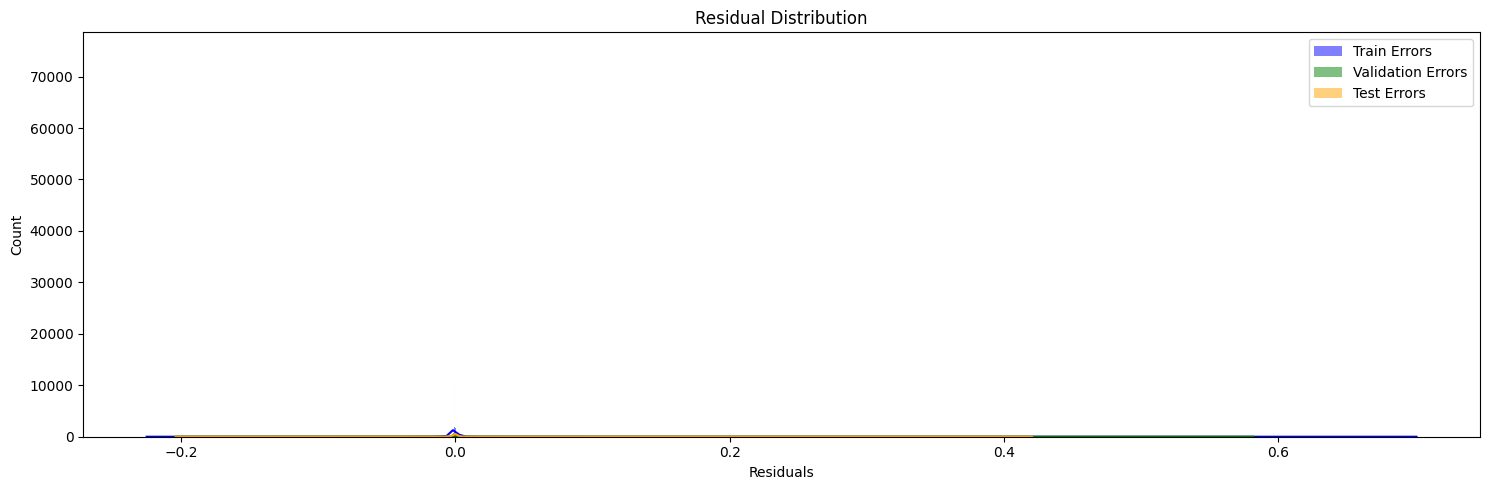

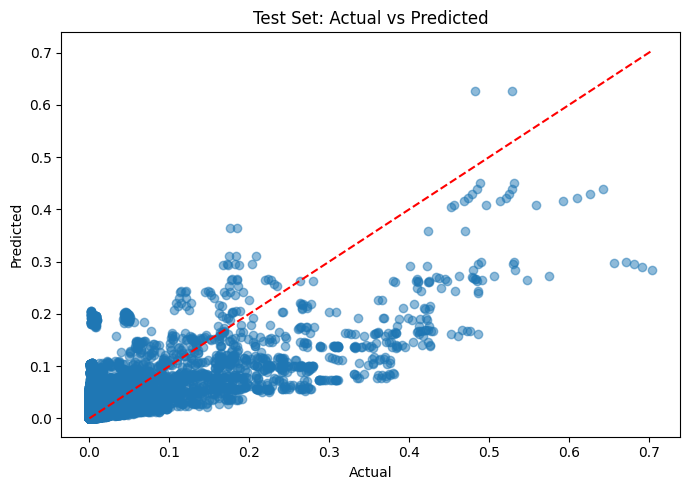

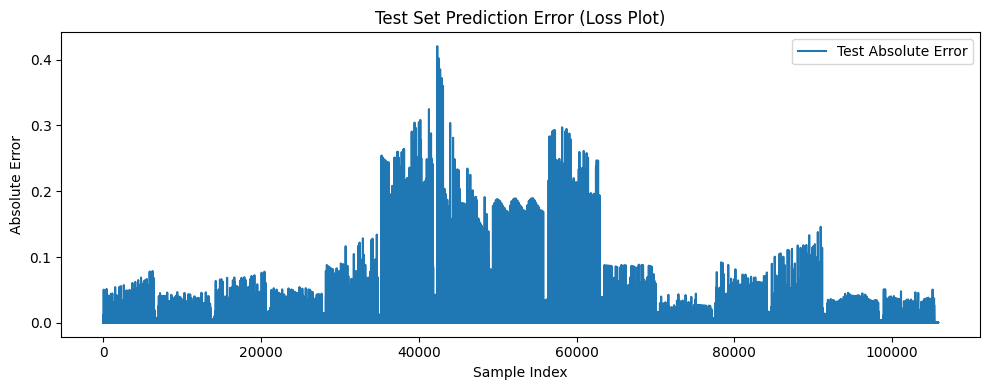

In [27]:
# === Train KNN Regressor ===
# Choose the number of neighbors (k) - common practice is odd numbers
# A simple starting point could be sqrt(number of samples) or cross-validation
k_neighbors = 5 # You can tune this parameter

KNNR = KNeighborsRegressor(n_neighbors=k_neighbors)

# Fit the model
KNNR.fit(train_x, train_y)

# === Predict ===
pred_train = KNNR.predict(train_x)
pred_val   = KNNR.predict(val_x)
pred_test  = KNNR.predict(test_x)

# === Print Model Summary ===
print(f"{'<'*3}{'-'*35} \033[1mEvaluating K-Nearest Neighbors Regressor\033[0m {'-'*35}{'>'*3}\n")
print(f"Number of Neighbors (k): {k_neighbors}")
print("KNN model trained successfully.")

# === Evaluate the Model ===
Evaluate(
    n=4,  # Assuming this is the 8th model (0-indexed)
    pred_train=pred_train,
    pred_val=pred_val,
    pred_test=pred_test,
    Train_X_std=train_x,
    Train_Y=train_y,
    Val_Y=val_y,
    Test_Y=test_y
)

# 8.0 Model Evaluation

## 8.1 Analyze Performance

In [28]:
# Models Results Evaluation
EMC = Model_Evaluation_Comparison_Matrix.copy()
EMC.index = ['Multiple Linear Regression','XGBoost','LightGBM','CatBoost','K-Nearest Neighbors Regression']

# Select only test-related columns
test_columns = [col for col in Model_Evaluation_Comparison_Matrix.columns if 'Test-' in col]
EMC_test = EMC[test_columns] # Display the filtered DataFrame
display(EMC_test)

,Test-R2,Test-RSS,Test-MSE,Test-RMSE,Test-MAE,Test-Samples,Test-MaxError,Test-MinError,Test-MedAE,Test-StdError
Multiple Linear Regression,0.000829,317520.0,0.005502,27.921699,0.008186,2.767306e-07,0.005007,0.025478,0.701272,0.024342
XGBoost,0.000231,317520.0,0.001241,9.155094,0.004636,5.962421e-08,0.704775,0.013878,0.453394,0.013080
LightGBM,0.000102,317520.0,0.000772,3.636771,0.003546,2.835322e-08,0.812619,0.011057,0.211437,0.010424
CatBoost,0.000296,317520.0,0.001185,11.318031,0.004893,4.920114e-08,0.640985,0.015304,0.519900,0.014513
K-Nearest Neighbors Regression,0.000392,317520.0,0.000357,12.589447,0.004434,0.000000e+00,0.579147,0.016570,0.420462,0.016046


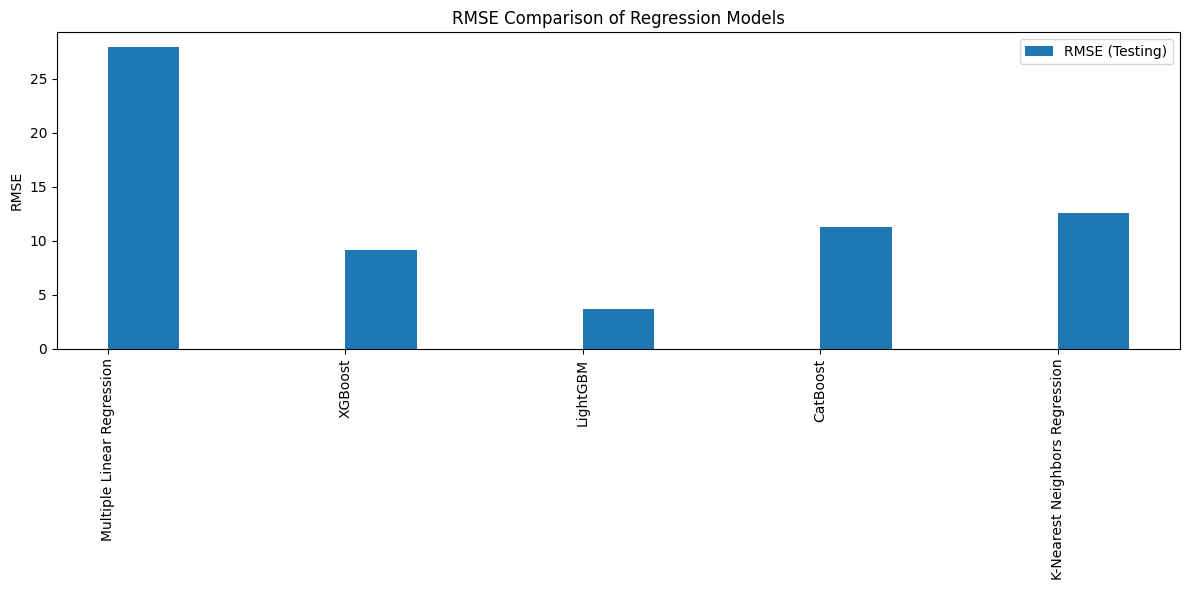

In [29]:
# Root Mean Squared Error Comparison for different Regression Models
cc = Model_Evaluation_Comparison_Matrix.columns.values
s = len(Model_Evaluation_Comparison_Matrix) # Set s to the number of rows in the DataFrame
plt.figure(figsize=(12, 6)) # Increase figure size for better readability
plt.bar(np.arange(s)+0.3, Model_Evaluation_Comparison_Matrix['Test-RMSE'].values, width=0.3, label='RMSE (Testing)') # Use column name
plt.xticks(np.arange(s) + 0.15, EMC.index, rotation=90) # Center x-ticks and use EMC index for labels
plt.ylabel('RMSE') # Add y-axis label
plt.title('RMSE Comparison of Regression Models') # Add title
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

### **LightGBM is the chosen model **

## 8.2 Hyperparameter Tuning (Future Implementation)

# 9.0 Explainable AI (XAI) Implementation

| **Aspect**                  | **SHAP (SHapley Additive Explanations)**                                                                 | **LIME (Local Interpretable Model-agnostic Explanations)**                                          | **PDP (Partial Dependence Plot)**                                                                |
|----------------------------|------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **Type**                   | Model-agnostic & model-specific                                                                            | Model-agnostic                                                                                      | Model-agnostic                                                                                   |
| **Interpretation**         | Global + Local (explains overall feature importance & individual predictions)                              | Local (explains individual predictions only)                                                         | Global (shows average effect of a feature on prediction)                                         |
| **Output**                 | Feature contribution values (positive or negative)                                                         | Local surrogate model with weights                                                                   | Line or surface plots showing marginal effect of features                                        |
| **Computation**            | More computationally intensive (especially on large datasets)                                              | Faster but may be less stable                                                                        | Simple to compute for low-dimensional data                                                       |
| **Consistency**            | Theoretically consistent with Shapley values (fairness from game theory)                                   | May vary depending on sampling/perturbation                                                          | Can be misleading with correlated features                                                       |
| **Use in Fisheries Forecasting** | Ideal for identifying key environmental or operational features driving predictions (e.g., temperature, gear type) | Good for debugging individual predictions (e.g., anomalies in certain years)                         | Useful to visualize how a single variable (e.g., rainfall) affects landings on average           |


## 9.1 SHAP (SHapley Additive exPlanations)

In [30]:
# --- SHAP Analysis for LGBM ---
# Initialize JS visualization in notebooks
shap.initjs()

# Create Tree explainer for LightGBM model
# shap.TreeExplainer works well with tree-based models like LightGBM, XGBoost, CatBoost, etc.
# We use the test set as the background dataset for the explainer.
explainer = shap.TreeExplainer(LGBMR, test_x)

### 9.1.1 Calculate SHAP values for the test set

In [ ]:
# Calculate SHAP values for the test set
# The calculation might take some time depending on the size of test_x and the model complexity.
shap_values = explainer.shap_values(test_x)

100%|===================| 105756/105840 [02:52<00:00]       

### 9.1.2 Summary Plot: Global feature importance and impact

SHAP summary plot: 


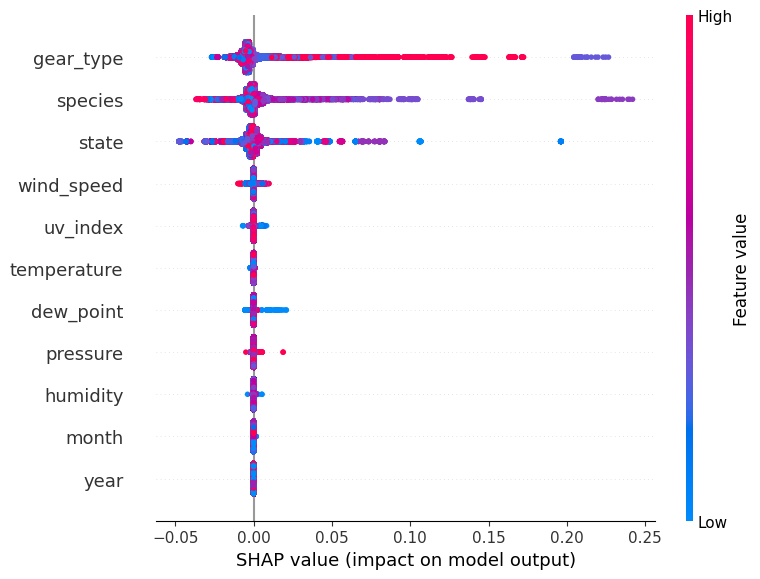

In [ ]:
# Summary Plot: Global feature importance and impact
# Shows the distribution of SHAP values for each feature.
# The x-axis represents the SHAP value.
# Each dot is an instance from the test set.
# The color represents the feature value (red high, blue low).
print("SHAP summary plot: ")
shap.summary_plot(shap_values, test_x, feature_names=test_x.columns)

### 9.1.3 Dependence Plot: Interaction effects or feature relationship with target prediction

SHAP dependence plot: 
Plotting dependence between 'gear_type' and 'species'...


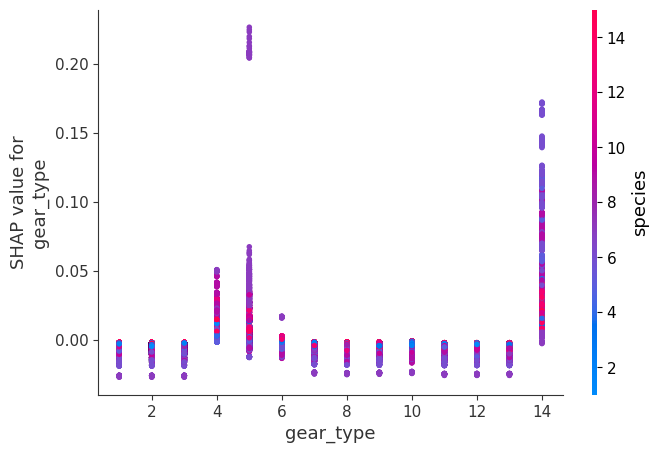

In [ ]:
# Dependence Plot: Interaction effects or feature relationship with target prediction
# Shows how the SHAP value for a single feature varies across the instances
# and how it might interact with another feature.
# Let's pick the most important feature from the summary plot (e.g., 'temperature')
# and another feature (e.g., 'humidity') to see the interaction.
# You can change 'temperature' and 'humidity' to features of interest based on the summary plot.
print("SHAP dependence plot: ")
# You can iterate through the top N features or pick specific ones
if len(test_x.columns) >= 2:
    # Example: dependence plot for the top 2 features
    top_features_indices = np.argsort(np.sum(np.abs(shap_values), axis=0))[::-1][:2]
    feature_1_name = test_x.columns[top_features_indices[0]]
    feature_2_name = test_x.columns[top_features_indices[1]]
    print(f"Plotting dependence between '{feature_1_name}' and '{feature_2_name}'...")
    shap.dependence_plot(feature_1_name, shap_values, test_x, interaction_index=feature_2_name, feature_names=test_x.columns)
elif len(test_x.columns) >= 1:
     # Example: dependence plot for the top 1 feature (no interaction)
    top_feature_index = np.argsort(np.sum(np.abs(shap_values), axis=0))[::-1][0]
    feature_name = test_x.columns[top_feature_index]
    print(f"Plotting dependence for '{feature_name}'...")
    shap.dependence_plot(feature_name, shap_values, test_x, feature_names=test_x.columns)
else:
    print("Not enough features to generate dependence plot.")

### 9.1.4 Force Plot: Explain a single prediction

In [ ]:
# print instance at index 0
test_x.iloc[0]

,21840
species,1.000000
month,1.000000
state,1.000000
gear_type,1.000000
year,2021.000000
temperature,0.279949
pressure,0.532055
dew_point,0.166946
humidity,0.443837
wind_speed,0.623169


In [ ]:
import shap
shap.initjs()

# Force Plot: Explain a single prediction
# Shows how each feature contributes to the prediction for a specific instance.
# You can choose any index from the test set (e.g., index 0).
print("SHAP force plot for an individual prediction: ")
# Choose an instance index (e.g., 0)
instance_index = 0
print(f"Explaining prediction for instance index {instance_index}")
shap.force_plot(explainer.expected_value, shap_values[instance_index,:], test_x.iloc[instance_index,:], feature_names=test_x.columns)

SHAP force plot for an individual prediction: 
Explaining prediction for instance index 0


### 9.1.5 Waterfall Plot: Explain a single prediction in detail (requires specific backend)



SHAP waterfall plot for instance index 0...


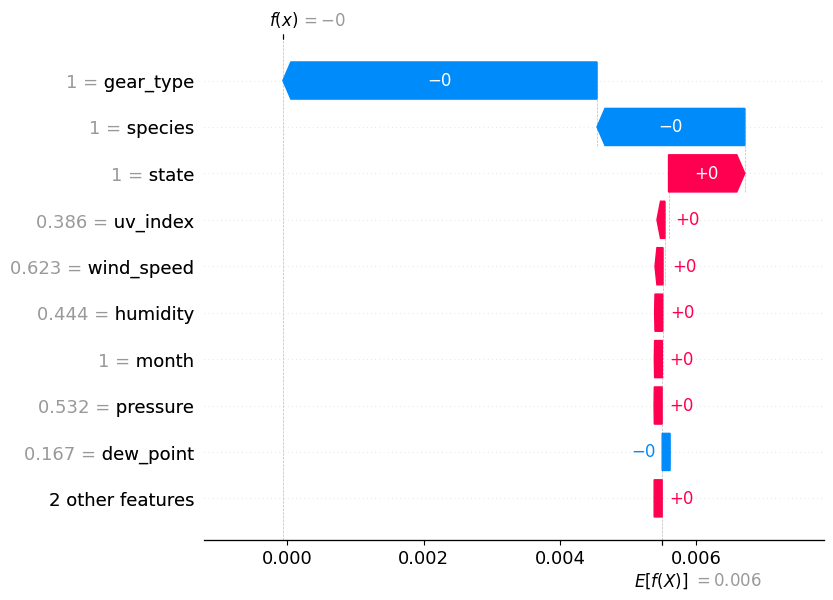

In [ ]:
# Waterfall Plot: Explain a single prediction in detail (requires specific backend)
# More detailed view of how each feature pushes the prediction from the base value to the final value.
# This often works well in notebooks, but the Force plot is more interactive.
# Let's plot the waterfall for the same instance as the single force plot.
print(f"SHAP waterfall plot for instance index {instance_index}...")
shap.waterfall_plot(shap.Explanation(values=shap_values[instance_index],
                                     base_values=explainer.expected_value,
                                     data=test_x.iloc[instance_index],
                                     feature_names=test_x.columns))

## 9.2 LIME (Local Interpretable Model-agnostic Explanations)


### 9.2.1 Lime Explainer

In [ ]:
# --- LIME Analysis for LGBM ---
# For tabular data, use LimeTabularExplainer.
# Need to provide training data, feature names, and class names (not relevant for regression).
# 'mode' should be 'regression' for regression tasks.
# 'training_data' should be a numpy array.
# 'feature_names' should be a list of feature names.
# 'discretize_continuous' can be set to True if you want to discretize continuous features for explanations.
print("Initializing LIME explainer...")
explainer_lime = lime_tabular.LimeTabularExplainer(
    training_data=train_x.values, # Use training data (as numpy array) for background distribution
    feature_names=train_x.columns.tolist(),
    mode='regression',
    discretize_continuous=True # Discretize continuous features for better explanations
)


Initializing LIME explainer...


### 9.2.2 Explain a single prediction

In [ ]:
# Explain a single prediction using LIME
# We can pick the same instance index used for SHAP (e.g., index 0).
instance_index_lime = 0
print(f"\nExplaining prediction for instance index {instance_index_lime} using LIME...")

# Get the instance data as a numpy array
instance_data = test_x.iloc[instance_index_lime].values

# Get the explanation for the instance
# 'num_features' determines how many features to include in the explanation.
explanation = explainer_lime.explain_instance(
    data_row=instance_data,
    predict_fn=LGBMR.predict, # The prediction function of your model
    num_features=len(test_x.columns) # Number of features to show in the explanation
)


Explaining prediction for instance index 0 using LIME...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Generating LIME explanation visualization...


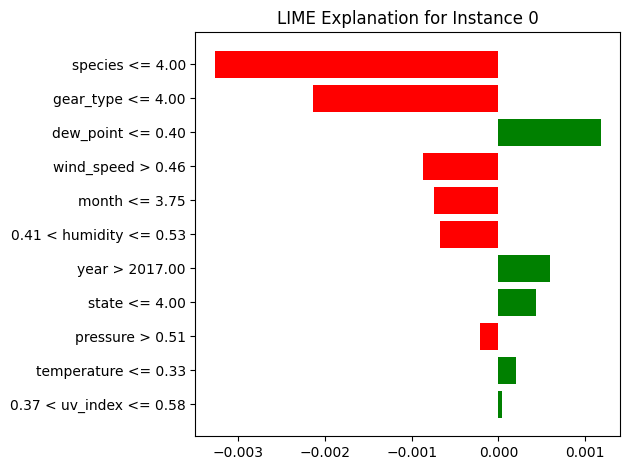

LIME explanation visualization generated.

LIME Explanation (as list of tuples):
[('species <= 4.00', -0.0032738459559120046), ('gear_type <= 4.00', -0.002134588492732076), ('dew_point <= 0.40', 0.0011799223577639657), ('wind_speed > 0.46', -0.0008744243240406174), ('month <= 3.75', -0.0007410149216274489), ('0.41 < humidity <= 0.53', -0.0006718652703443783), ('year > 2017.00', 0.0005973710993194641), ('state <= 4.00', 0.0004311857230735725), ('pressure > 0.51', -0.00021250485732309478), ('temperature <= 0.33', 0.00020594261847107194), ('0.37 < uv_index <= 0.58', 4.01793647787735e-05)]
--------------------------------------------------


In [ ]:
# Visualize the explanation
# This will show the feature contributions for the specific instance.
print("Generating LIME explanation visualization...")
explanation.as_pyplot_figure()
plt.title(f"LIME Explanation for Instance {instance_index_lime}")
plt.tight_layout()
plt.show()
print("LIME explanation visualization generated.")

# Alternatively, you can print the explanation as a list of tuples (feature, weight)
print("\nLIME Explanation (as list of tuples):")
print(explanation.as_list())
print("-" * 50)

## 9.3 PDP (Partial Dependence Plots)

In [ ]:
# # --- Partial Dependence Plots (PDP) for LGBM ---

# # PDPs show the marginal effect of one or two features on the predicted outcome
# # of a machine learning model.

# # Let's pick some features to visualize their effect on 'landings'.
# # You can choose features you expect to be important based on the SHAP/LIME analysis or domain knowledge.
# # For example, temperature, humidity, and species might be good candidates.
# features_to_plot = ['temperature', 'humidity', 'species', ('temperature', 'humidity')]

# # Ensure the features exist in the test set
# existing_features = [f for f in features_to_plot if (isinstance(f, str) and f in test_x.columns) or
#                      (isinstance(f, tuple) and all(item in test_x.columns for item in f))]
# if len(existing_features) != len(features_to_plot):
#     print("Warning: Some requested features for PDP do not exist in the DataFrame.")
#     print("Features not found:", set(features_to_plot) - set(existing_features))

# if not existing_features:
#     print("No valid features found to generate PDPs.")
# else:
#     print("\nGenerating Partial Dependence Plots for LGBM...")

#     # Create the PDP display
#     # `estimator` is the trained model (LGBMR in this case)
#     # `X` is the data used to compute the PDP (often the training or test set)
#     # `features` is the list of features (or pairs) to plot
#     # `feature_names` are the names to display on the plots
#     # `target` is the index of the target class for classification (not needed for regression)
#     # `grid_resolution` determines the number of points where the partial dependence is evaluated
#     # `percentiles` define the percentiles of the feature distribution to plot 1-way PDP
#     # `n_jobs` for parallel computation

#     display = PartialDependenceDisplay.from_estimator(
#         estimator=LGBMR,
#         X=test_x, # Use test set for computation
#         features=existing_features,
#         feature_names=test_x.columns.tolist(),
#         # grid_resolution=50, # You can adjust this
#         # percentiles=(0.05, 0.95), # You can adjust this
#         # n_jobs=-1 # Use all available cores
#     )

#     # Adjust plot layout
#     display.figure_.suptitle('Partial Dependence Plots for LightGBM Regressor')
#     plt.subplots_adjust(top=0.9) # Add space for the title
#     plt.show()
#     print("Partial Dependence Plots generated.")

# # Interpretation:
# # - For 1-way PDPs (e.g., 'temperature'), the plot shows the average predicted 'landings' as 'temperature' changes, holding other features constant at their average effect.
# # - For 2-way PDPs (e.g., ('temperature', 'humidity')), the plot is a heatmap showing the combined effect of 'temperature' and 'humidity' on the predicted 'landings'.

# # You can iterate through the top features identified by SHAP or LIME and generate PDPs for them
# # to understand their individual and potentially combined effects on the predictions.

## 9.4 Permutation Importance

/tmp/ipython-input-187638777.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T,


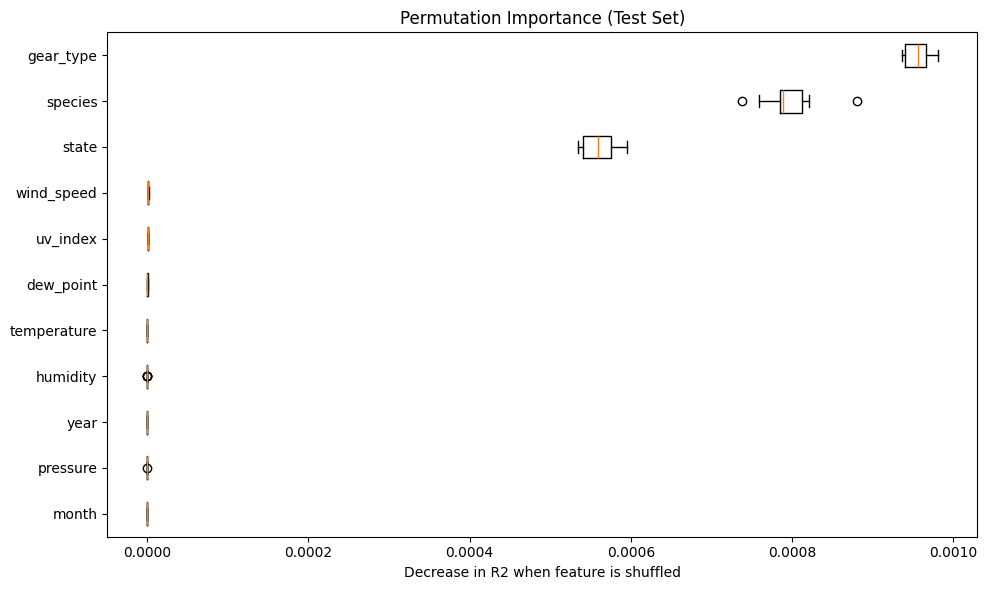


Permutation Importance (Mean and Std Dev):
gear_type           0.001 +/- 0.000
species             0.001 +/- 0.000
state               0.001 +/- 0.000
wind_speed          0.000 +/- 0.000
uv_index            0.000 +/- 0.000
dew_point           0.000 +/- 0.000
temperature         0.000 +/- 0.000
humidity            0.000 +/- 0.000
year                0.000 +/- 0.000
pressure            -0.000 +/- 0.000
month               -0.000 +/- 0.000


In [ ]:
# --- Permutation Importance for LGBM ---

# Permutation Importance measures the increase in the model's prediction error
# after permuting the feature's values, which breaks the relationship between
# the feature and the target.

# Calculate permutation importance on the test set
# `estimator` is the trained model (LGBMR in this case)
# `X` is the data to evaluate on (test_x)
# `y` is the true target values for X (test_y)
# `scoring` is the metric to use (e.g., 'neg_mean_squared_error' for regression)
# `n_repeats` is the number of times to permute a feature
# `random_state` for reproducibility
# `n_jobs` for parallel processing

result = permutation_importance(
    estimator=LGBMR,
    X=test_x,
    y=test_y,
    scoring='neg_mean_squared_error', # Use a suitable regression scoring metric
    n_repeats=10, # Number of permutations per feature
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Sort the features by importance
sorted_idx = result.importances_mean.argsort()

# Plot the permutation importance
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[sorted_idx].T,
            vert=False, labels=test_x.columns[sorted_idx])
plt.title("Permutation Importance (Test Set)")
plt.xlabel(f"Decrease in R2 when feature is shuffled") # Adjust label based on scoring metric
plt.tight_layout()
plt.show()

# You can also access the mean importance and standard deviation
print("\nPermutation Importance (Mean and Std Dev):")
for i in sorted_idx[::-1]: # Print from most important to least
    print(f"{test_x.columns[i]:<20}"
          f"{result.importances_mean[i]:.3f} +/- {result.importances_std[i]:.3f}")

## 9.5 Surrogate Decision Tree

### 9.5.1 Train Surrogate Decision Tree

In [ ]:
# prompt: do surrogate decision tree
print("\n" + "="*20 + " Surrogate Decision Tree " + "="*20)

# 1. Train the complex model (using LGBMR as the example complex model)
#    The LGBMR model is already trained in the preceding code.

# 2. Generate predictions from the complex model on the training data
#    We use the training data to train the surrogate model.
complex_model_train_predictions = LGBMR.predict(train_x)

# 3. Train a simple surrogate model (Decision Tree Regressor) on the training data
#    using the complex model's predictions as the target.
#    Choose a shallow max_depth to make the tree easily interpretable.
surrogate_tree = DecisionTreeRegressor(max_depth=3, random_state=42)

print("\nTrain Surrogate Decision Tree...")
surrogate_tree.fit(train_x, complex_model_train_predictions)


==================== Surrogate Decision Tree ====================

Train Surrogate Decision Tree...


DecisionTreeRegressor(max_depth=3, random_state=42)

### 9.5.2 Evaluate Surrogate Model

In [ ]:
# 4. Evaluate the surrogate model (optional but recommended)
#    How well does the surrogate model mimic the complex model's predictions?
surrogate_train_pred = surrogate_tree.predict(train_x)
surrogate_val_pred = surrogate_tree.predict(val_x) # Predict on validation set too

surrogate_r2_train = r2_score(complex_model_train_predictions, surrogate_train_pred)
surrogate_mse_train = mean_squared_error(complex_model_train_predictions, surrogate_train_pred)

complex_model_val_predictions = LGBMR.predict(val_x)
surrogate_r2_val = r2_score(complex_model_val_predictions, surrogate_val_pred)
surrogate_mse_val = mean_squared_error(complex_model_val_predictions, surrogate_val_pred)

print(f"\nSurrogate Tree R2 Score (Train Data vs LGBM Preds): {surrogate_r2_train:.4f}")
print(f"Surrogate Tree MSE (Train Data vs LGBM Preds): {surrogate_mse_train:.4f}")
print(f"Surrogate Tree R2 Score (Validation Data vs LGBM Preds): {surrogate_r2_val:.4f}")
print(f"Surrogate Tree MSE (Validation Data vs LGBM Preds): {surrogate_mse_val:.4f}")

# A high R2 and low MSE indicate the surrogate tree captures the complex model's behavior well.


Surrogate Tree R2 Score (Train Data vs LGBM Preds): 0.2679
Surrogate Tree MSE (Train Data vs LGBM Preds): 0.0004
Surrogate Tree R2 Score (Validation Data vs LGBM Preds): 0.2320
Surrogate Tree MSE (Validation Data vs LGBM Preds): 0.0004



Plotting Surrogate Decision Tree...


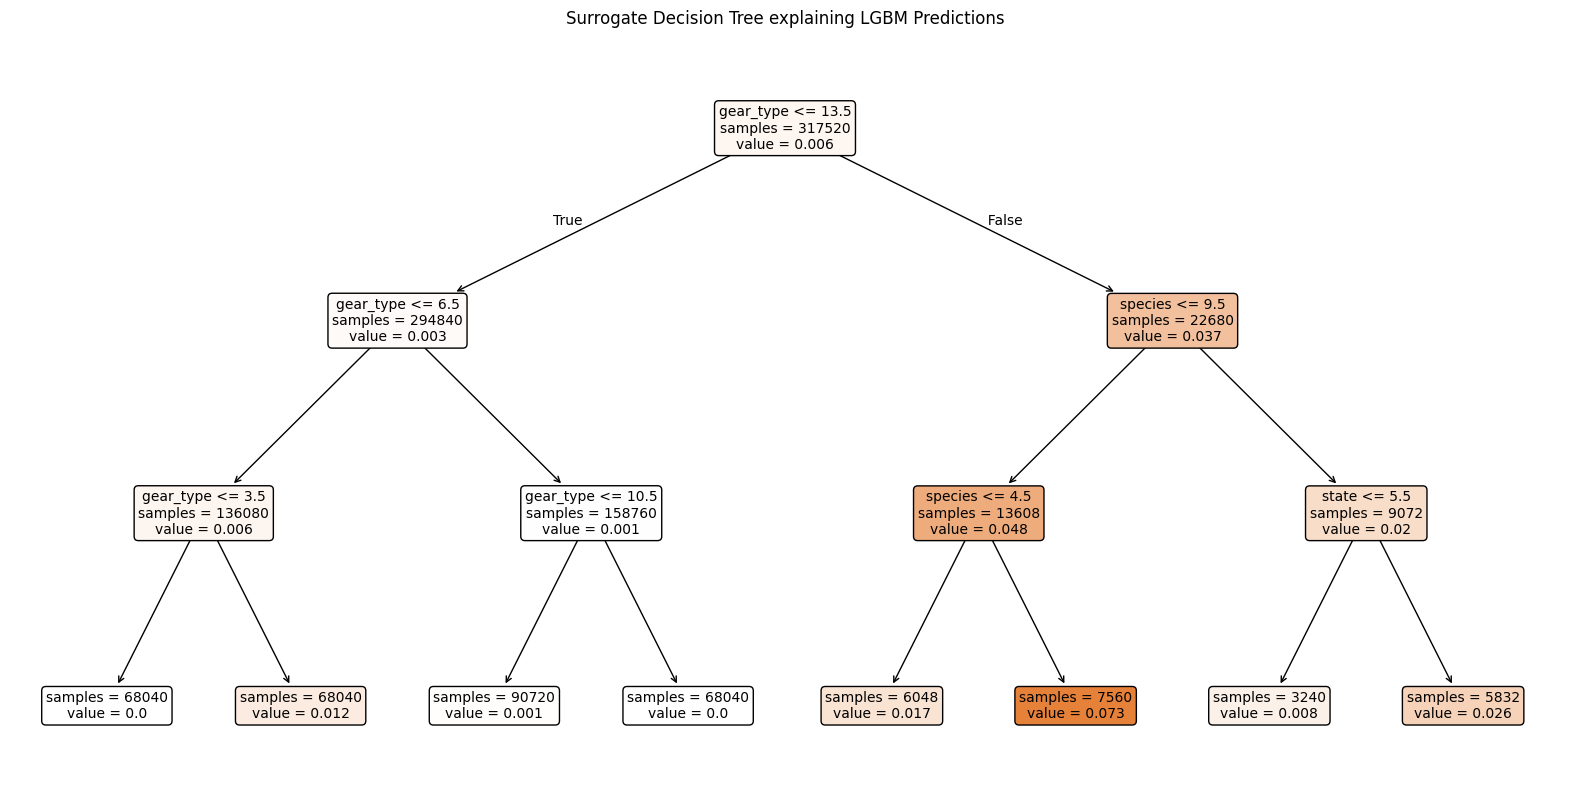

In [ ]:
# 5. Visualize the Surrogate Decision Tree
print("\nPlotting Surrogate Decision Tree...")
plt.figure(figsize=(20, 10)) # Adjust figure size as needed
plot_tree(surrogate_tree,
          feature_names=train_x.columns.tolist(),
          filled=True,
          rounded=True,
          impurity=False,
          fontsize=10)
plt.title("Surrogate Decision Tree explaining LGBM Predictions")
plt.show()

### 9.5.3 Interpret Surrogate Tree

In [ ]:
# 6. Interpret the Surrogate Tree
#    The tree visually shows the decision rules learned by the simple model to mimic
#    the complex model's output.
#    - Each node represents a decision based on a feature and threshold.
#    - The 'value' in each leaf node is the predicted 'landings' value by the surrogate tree
#      for instances falling into that leaf.
#    - By following paths from the root to the leaves, you can understand the feature
#      combinations that lead to certain prediction ranges according to the complex model.

print("\nInterpretation:")
print("The plotted tree represents a simplified version of the LGBM model's decision logic.")
print(f"With a max_depth of {surrogate_tree.max_depth}, it's easier to see which features")
print("and decision rules are most influential in determining the prediction.")
print("Each path from the root to a leaf node corresponds to a rule, and the leaf value")
print("shows the expected outcome for instances satisfying that rule.")
print("Higher importance features tend to appear closer to the root.")


Interpretation:
The plotted tree represents a simplified version of the LGBM model's decision logic.
With a max_depth of 3, it's easier to see which features
and decision rules are most influential in determining the prediction.
Each path from the root to a leaf node corresponds to a rule, and the leaf value
shows the expected outcome for instances satisfying that rule.
Higher importance features tend to appear closer to the root.


# 10.0 Forecast 2024 - 2026 Fisheries Landing  

## 10.1 Forecast Data Sample

In [ ]:
# === Forecast 2024-2026 Fisheries Landing ===

# The task is to forecast landings for the years 2024, 2025, and 2026 using the
# best performing model, which is LightGBM (LGBMR) based on the previous evaluation.

# To make forecasts, we need to create a DataFrame with future data points (features)
# for the years 2024-2026.

# The features required for forecasting must match the features used to train the LGBMR model.
# These features are: 'species', 'state', 'gear_type', 'temperature', 'pressure',
# 'dew_point', 'humidity', 'wind_speed', 'uv_index', 'month', 'year'.

# We need to generate realistic or representative values for these features for
# the future years. Since we don't have actual weather data for 2024-2026,
# a common approach is to use historical patterns.

# Option 1: Use average values per month/species/state/gear_type from historical data
# Option 2: Repeat the patterns from the most recent historical year (2023)
# Option 3: Use the last known values

# Let's use a combination: we will generate data points for each month, species,
# state, and gear type combination present in the dataset and use the average
# weather data from the historical data for those combinations.

print("\n" + "="*20 + " Forecasting Fisheries Landing (2024-2026) " + "="*20)

# Identify the unique combinations of 'species', 'state', 'gear_type', and 'month'
# from the historical data (excluding the test set year to be safe, maybe use 2011-2023 data)
# Or, more simply, use all unique combinations from the entire df_encoded used for splitting.
unique_combinations = df_encoded[['species', 'state', 'gear_type', 'month']].drop_duplicates()

print(f"\nGenerating forecast data points based on {len(unique_combinations)} unique combinations...")

forecast_data_list = []

# Define the years to forecast
forecast_years = [2024, 2025, 2026]

# Calculate the average weather data per unique combination from the historical data
# We'll use the entire df_encoded to capture broader patterns
average_weather_data = df_encoded.groupby(['species', 'state', 'gear_type', 'month'])[
    ['temperature', 'pressure', 'dew_point', 'humidity', 'wind_speed', 'uv_index']
].mean().reset_index()

# Create forecast data points for each forecast year
for year in forecast_years:
    # Merge the unique combinations with the average weather data
    forecast_df_year = unique_combinations.merge(
        average_weather_data,
        on=['species', 'state', 'gear_type', 'month'],
        how='left' # Use left merge to keep all combinations, some might not have weather data average
    )

    # Fill NaN values in weather features if a combination didn't exist in the average data calculation
    # (e.g., a species caught in a state/gear type only in a year not used for average).
    # A simple approach is to fill with the global average of that feature, or a more sophisticated
    # approach involves filling based on the nearest available combination.
    # For simplicity, let's fill with global feature means from the training data.
    for col in ['temperature', 'pressure', 'dew_point', 'humidity', 'wind_speed', 'uv_index']:
        if col in forecast_df_year.columns:
            global_mean = train_x[col].mean() # Use training data means
            forecast_df_year[col] = forecast_df_year[col].fillna(global_mean)

    # Add the 'year' column
    forecast_df_year['year'] = year

    # Ensure all required features are present in the correct order and filled
    required_features = train_x.columns.tolist() # Use the training features order
    # Drop 'landings' if it somehow made it into the merge (it shouldn't with this approach)
    if 'landings' in forecast_df_year.columns:
        forecast_df_year = forecast_df_year.drop(columns=['landings'])

    # Reindex the DataFrame to match the training data columns
    # This is crucial for the model prediction input
    missing_cols = set(required_features) - set(forecast_df_year.columns)
    if missing_cols:
        print(f"Warning: Missing required features in forecast data: {missing_cols}")
        # Add missing columns with default values (e.g., 0 or mean from train_x)
        for col in missing_cols:
             forecast_df_year[col] = train_x[col].mean() # Using mean as default

    # Ensure columns are in the same order as train_x
    forecast_df_year = forecast_df_year[required_features]


    forecast_data_list.append(forecast_df_year)

# Concatenate the data for all forecast years
forecast_df = pd.concat(forecast_data_list, ignore_index=True)

print(f"\nGenerated forecast DataFrame with shape: {forecast_df.shape}")
print("Forecast data sample:")
print(forecast_df.head())


==================== Forecasting Fisheries Landing (2024-2026) ====================

Generating forecast data points based on 35280 unique combinations...

Generated forecast DataFrame with shape: (105840, 11)
Forecast data sample:
   species  month  state  gear_type  year  temperature  pressure  dew_point  \
0        1      1      1          1  2024     0.237229  0.553076   0.154507   
1        1      1      1          2  2024     0.237229  0.553076   0.154507   
2        1      1      1          3  2024     0.237229  0.553076   0.154507   
3        1      1      1          4  2024     0.237229  0.553076   0.154507   
4        1      1      1          5  2024     0.237229  0.553076   0.154507   

   humidity  wind_speed  uv_index  
0  0.410193    0.665507  0.310841  
1  0.410193    0.665507  0.310841  
2  0.410193    0.665507  0.310841  
3  0.410193    0.665507  0.310841  
4  0.410193    0.665507  0.310841  


## 10.2 Make Prediction using the chosen model (LGBMR)


In [ ]:
# === Make Predictions using the chosen model (LGBMR) ===
print("\nMaking forecasts using the LightGBM model...")
forecast_predictions_scaled = LGBMR.predict(forecast_df)

# The predictions are on the scaled 'landings' scale.
# We need to inverse transform them back to the original scale.
# The scaler was fitted on the original 'landings' column.

# Create a dummy DataFrame with the scaled predictions to use the scaler's inverse_transform
# The scaler expects a 2D array where the feature column is in the correct position.
# We need to create a temporary DataFrame that looks like the original df_encoded
# but only contains the predicted 'landings' values at the correct column index,
# while other columns can be dummy values (they won't affect the inverse transform of 'landings').

# Find the column index of 'landings' in the original scaled data
landings_col_index = df_encoded.columns.get_loc('landings')
num_cols = df_encoded.shape[1] # Total number of columns in df_encoded

# Create a dummy array of the same shape as df_encoded but with only the predicted 'landings'
dummy_scaled_data = np.zeros((len(forecast_predictions_scaled), num_cols))
dummy_scaled_data[:, landings_col_index] = forecast_predictions_scaled

# Inverse transform the dummy data
# This will correctly inverse transform the 'landings' column while ignoring others
# Note: The inverse_transform expects the same shape as the data it was fitted on.
# The scaler was fitted on `df_encoded[existing_numerical_cols]`.
# A more robust way is to just create a dummy array for the *numerical* columns
# that the scaler was fitted on.

# Re-initialize and fit the scaler on the original landings column ONLY if needed.
# However, since `scaler` was fitted on multiple numerical columns in the previous step,
# we must provide data with the same number of numerical columns in the correct order.

# Let's create a dummy array for ALL columns in df_encoded and place the predictions
# in the 'landings' column index. This seems the most straightforward way given how the
# scaler was fitted on `df_encoded[existing_numerical_cols]`.
dummy_df_for_inverse = pd.DataFrame(np.zeros((len(forecast_predictions_scaled), df_encoded.shape[1])),
                                    columns=df_encoded.columns)

# Place the scaled predictions into the 'landings' column of this dummy DataFrame
dummy_df_for_inverse['landings'] = forecast_predictions_scaled

# Apply the inverse transform. The scaler will only transform the columns it was fitted on.
# We need to make sure the columns in `dummy_df_for_inverse` match the columns
# used when the scaler was fitted (`existing_numerical_cols`).
# The order matters!

# Let's recreate the exact DataFrame structure the scaler expects for inverse transform.
# It was fitted on `df_encoded[existing_numerical_cols]`.
dummy_scaled_numerical_data = pd.DataFrame(np.zeros((len(forecast_predictions_scaled), len(existing_numerical_cols))),
                                           columns=existing_numerical_cols)

# Find the index of 'landings' within the `existing_numerical_cols` list
try:
    landings_index_in_numerical = existing_numerical_cols.index('landings')
    dummy_scaled_numerical_data['landings'] = forecast_predictions_scaled # Place scaled predictions in the landings column
    # Inverse transform the numerical columns
    inverse_transformed_numerical_data = scaler.inverse_transform(dummy_scaled_numerical_data)

    # Extract the inverse transformed 'landings' column
    forecast_landings_original_scale = inverse_transformed_numerical_data[:, landings_index_in_numerical]

except ValueError:
    print("Error: 'landings' not found in the columns used for scaling.")
    forecast_landings_original_scale = forecast_predictions_scaled # Cannot inverse transform

# Ensure predictions are non-negative
forecast_landings_original_scale[forecast_landings_original_scale < 0] = 0


# Add the forecasts to the forecast DataFrame
forecast_df['predicted_landings'] = forecast_landings_original_scale

print("\nForecasts generated:")
print(forecast_df.head())



Making forecasts using the LightGBM model...

Forecasts generated:
   species  month  state  gear_type  year  temperature  pressure  dew_point  \
0        1      1      1          1  2024     0.237229  0.553076   0.154507   
1        1      1      1          2  2024     0.237229  0.553076   0.154507   
2        1      1      1          3  2024     0.237229  0.553076   0.154507   
3        1      1      1          4  2024     0.237229  0.553076   0.154507   
4        1      1      1          5  2024     0.237229  0.553076   0.154507   

   humidity  wind_speed  uv_index  predicted_landings  
0  0.410193    0.665507  0.310841            0.000000  
1  0.410193    0.665507  0.310841            0.000000  
2  0.410193    0.665507  0.310841            0.000000  
3  0.410193    0.665507  0.310841           12.204309  
4  0.410193    0.665507  0.310841            0.000000  


## 10.3 Analyze and Visualize Forecasts


Monthly Forecasts (sample):
   year  month  predicted_landings
0  2024      1        21301.579501
1  2024      2        21412.716557
2  2024      3        21422.434368
3  2024      4        21253.075746
4  2024      5        21548.291718


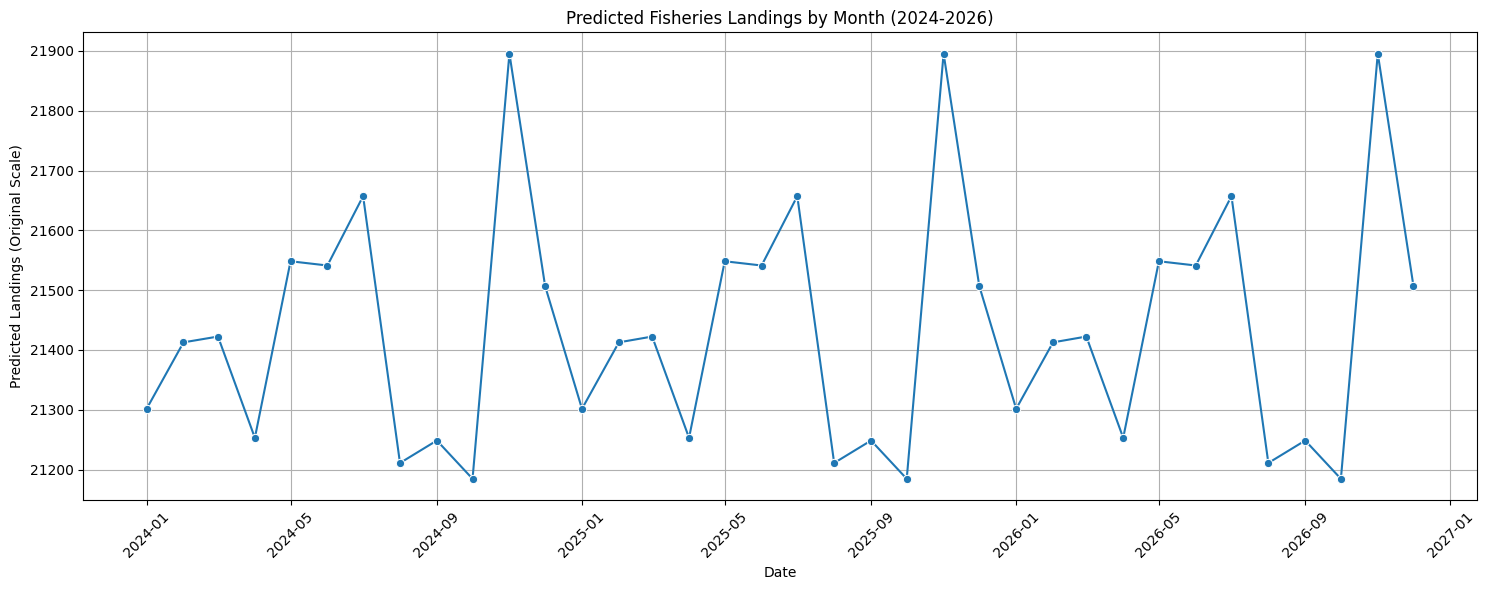

In [ ]:
# === Analyze and Visualize Forecasts ===

# Aggregate forecasts by year or year and month for overall trends
monthly_forecasts = forecast_df.groupby(['year', 'month'])['predicted_landings'].sum().reset_index()

print("\nMonthly Forecasts (sample):")
print(monthly_forecasts.head())

# Visualize monthly forecasts
# Convert year and month to a combined period for plotting
monthly_forecasts['period'] = pd.to_datetime(monthly_forecasts['year'].astype(str) + '-' + monthly_forecasts['month'].astype(str) + '-01')
monthly_forecasts = monthly_forecasts.sort_values('period')

plt.figure(figsize=(15, 6))
sns.lineplot(x='period', y='predicted_landings', data=monthly_forecasts, marker='o')
plt.title('Predicted Fisheries Landings by Month (2024-2026)')
plt.xlabel('Date')
plt.ylabel('Predicted Landings (Original Scale)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Further analysis could include:
# - Forecasting for specific species/states/gear types
# - Adding confidence intervals (more complex, might require bootstrapping or probabilistic models)
# - Comparing forecast patterns to historical patterns
# - Investigating sensitivity of forecasts to changes in input features (e.g., weather)

In [ ]:
# decode the categorical data of the forecasted value only

# The 'species', 'state', and 'gear_type' columns in `forecast_df` are still encoded.
# To make the forecast results interpretable in terms of original categories,
# we need to inverse transform these columns.

# We need to use the original encoder object `encoder` that was fitted
# on the `df_cleaned` DataFrame.

# First, create copies of the forecast DataFrame columns that need decoding
forecast_df_decoded = forecast_df.copy()

# Create a dummy DataFrame with only the columns to be decoded,
# ensuring the data types match the data the encoder was fitted on.
# The encoder was fitted on integer/float representations after initial encoding.
cols_to_decode = ['species', 'state', 'gear_type']

# Create a temporary DataFrame with just the encoded categorical columns
temp_encoded_df = forecast_df[cols_to_decode].copy()

# Apply the inverse transformation using the fitted encoder
# Note: OrdinalEncoder doesn't have a direct `inverse_transform` method
# that takes a DataFrame and column names like some other encoders.
# We need to manually map back using the category_mapping.

# Let's reconstruct the original values using the category mapping
# The category_mapping is a list of dictionaries for each column encoded.
# encoder.category_mapping[0] is for 'species'
# encoder.category_mapping[1] is for 'state'
# encoder.category_mapping[2] is for 'gear_type'

# Each mapping is a dictionary like {'col': 'species', 'mapping': {1: 'species_name_1', 2: 'species_name_2', ...}}
# We need to create inverse mappings: {encoded_value: original_category}

inverse_mappings = {}
for mapping_info in encoder.category_mapping:
    col_name = mapping_info['col']
    # Create inverse mapping dictionary
    inv_map = {encoded_val: original_cat for original_cat, encoded_val in mapping_info['mapping'].items()}
    inverse_mappings[col_name] = inv_map

# Decode each column in the forecast_df_decoded DataFrame
for col in cols_to_decode:
    if col in forecast_df_decoded.columns and col in inverse_mappings:
        # Use the map function with the inverse mapping dictionary
        # Ensure the column is of type that can be mapped (e.g., int)
        forecast_df_decoded[col] = forecast_df_decoded[col].map(inverse_mappings[col]).fillna('Unknown') # Handle potential NaNs

# Now, `forecast_df_decoded` contains the original categorical values for
# 'species', 'state', and 'gear_type', along with the predicted 'landings'
# and other features.

print("\nForecast Data with Decoded Categorical Features:")
print(forecast_df_decoded.head())


Forecast Data with Decoded Categorical Features:
              species  month  state             gear_type  year  temperature  \
0  AluAluKacangKacang      1  Kedah  Anchovy Purse Seines  2024     0.237229   
1  AluAluKacangKacang      1  Kedah              Bag Nets  2024     0.237229   
2  AluAluKacangKacang      1  Kedah          Barrier Nets  2024     0.237229   
3  AluAluKacangKacang      1  Kedah       Drift/Gill Nets  2024     0.237229   
4  AluAluKacangKacang      1  Kedah     Fish Purse Seines  2024     0.237229   

   pressure  dew_point  humidity  wind_speed  uv_index  predicted_landings  
0  0.553076   0.154507  0.410193    0.665507  0.310841            0.000000  
1  0.553076   0.154507  0.410193    0.665507  0.310841            0.000000  
2  0.553076   0.154507  0.410193    0.665507  0.310841            0.000000  
3  0.553076   0.154507  0.410193    0.665507  0.310841           12.204309  
4  0.553076   0.154507  0.410193    0.665507  0.310841            0.000000  


### 10.3.1 By Species

In [ ]:
# === Visualize Forecasts By Species ===

if 'predicted_species_decoded' in forecast_df.columns:
    print("\nVisualizing Forecasts By Species...")

    # Aggregate forecasts by year, month, and decoded species
    monthly_species_forecasts = forecast_df.groupby(['year', 'month', 'predicted_species_decoded'])['predicted_landings'].sum().reset_index()

    # Convert year and month to a combined period for plotting
    monthly_species_forecasts['period'] = pd.to_datetime(
        monthly_species_forecasts['year'].astype(str) + '-' + monthly_species_forecasts['month'].astype(str) + '-01'
    )
    monthly_species_forecasts = monthly_species_forecasts.sort_values(['predicted_species_decoded', 'period'])

    # Get the list of unique species for plotting
    unique_species = monthly_species_forecasts['predicted_species_decoded'].unique()

    # Plotting each species' forecast
    plt.figure(figsize=(18, 8)) # Adjust figure size

    # Use hue to plot different species as separate lines
    sns.lineplot(x='period', y='predicted_landings', hue='predicted_species_decoded', data=monthly_species_forecasts, marker='o')

    plt.title('Predicted Fisheries Landings by Month and Species (2024-2026)')
    plt.xlabel('Date')
    plt.ylabel('Predicted Landings (Original Scale)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title='Species') # Add legend for species
    plt.tight_layout()
    plt.show()

else:
    print("\nDecoded 'species' column not available. Cannot visualize forecasts by species.")
    print("Ensure the 'species' column was successfully decoded in the previous step.")


Decoded 'species' column not available. Cannot visualize forecasts by species.
Ensure the 'species' column was successfully decoded in the previous step.


### 10.3.2 By State


Visualizing Forecasts By State...


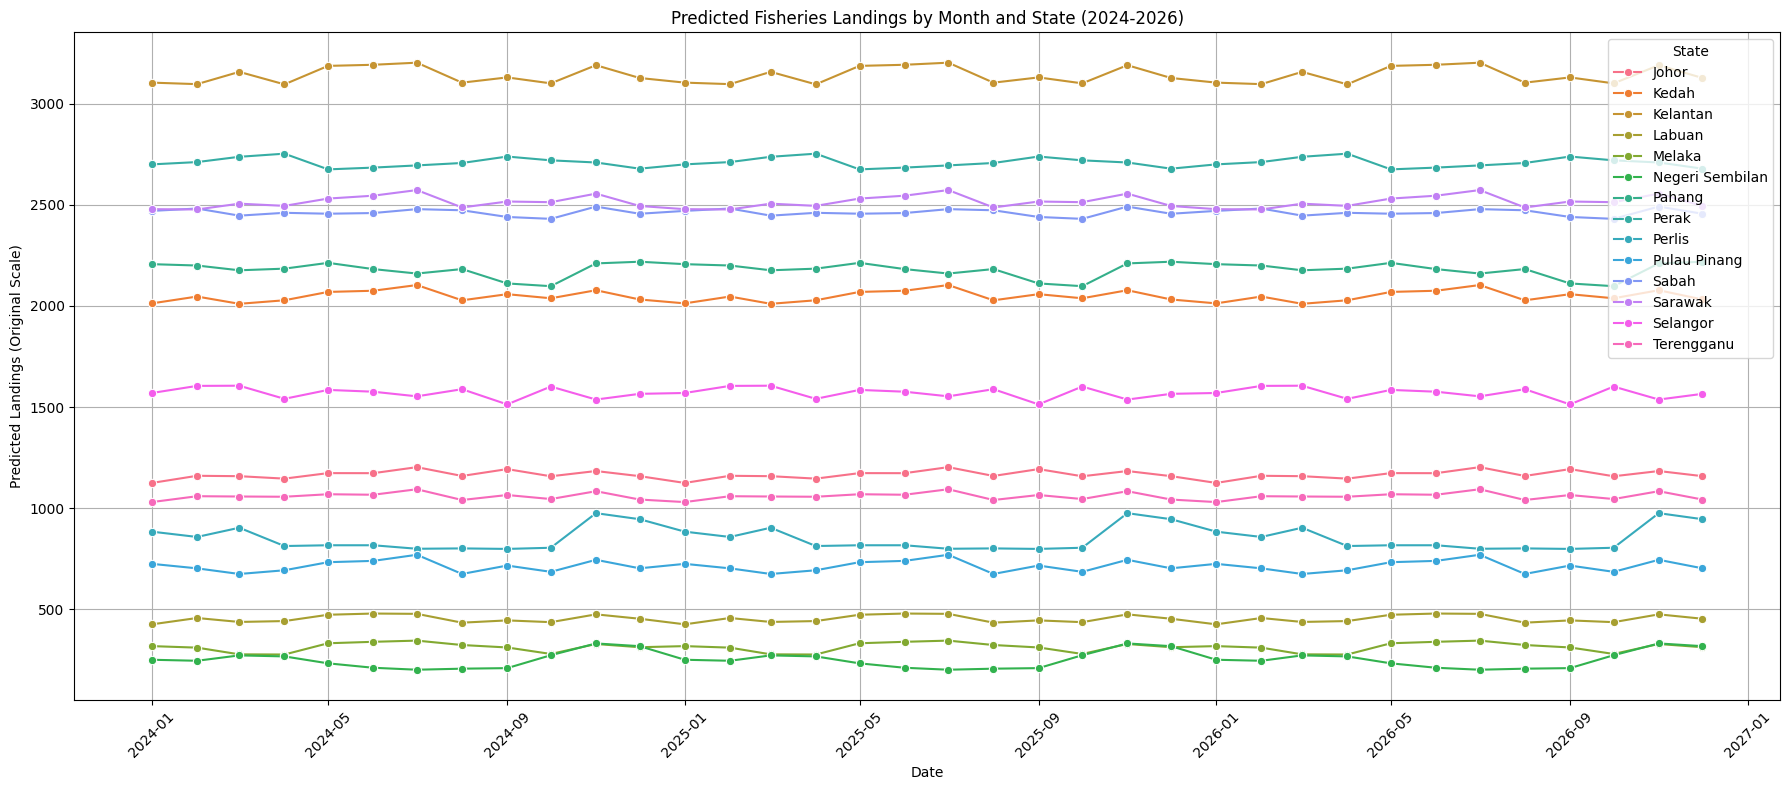

In [ ]:
# === Visualize Forecasts By State ===

if 'state' in forecast_df_decoded.columns:
    print("\nVisualizing Forecasts By State...")

    # Aggregate forecasts by year, month, and state
    monthly_state_forecasts = forecast_df_decoded.groupby(['year', 'month', 'state'])['predicted_landings'].sum().reset_index()

    # Convert year and month to a combined period for plotting
    monthly_state_forecasts['period'] = pd.to_datetime(
        monthly_state_forecasts['year'].astype(str) + '-' + monthly_state_forecasts['month'].astype(str) + '-01'
    )
    monthly_state_forecasts = monthly_state_forecasts.sort_values(['state', 'period'])

    # Get the list of unique states for plotting
    unique_states = monthly_state_forecasts['state'].unique()

    # Plotting each state's forecast
    plt.figure(figsize=(18, 8)) # Adjust figure size

    # Use hue to plot different states as separate lines
    sns.lineplot(x='period', y='predicted_landings', hue='state', data=monthly_state_forecasts, marker='o')

    plt.title('Predicted Fisheries Landings by Month and State (2024-2026)')
    plt.xlabel('Date')
    plt.ylabel('Predicted Landings (Original Scale)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title='State') # Add legend for state
    plt.tight_layout()
    plt.show()

else:
    print("\nDecoded 'state' column not available. Cannot visualize forecasts by state.")

### 10.3.3 By Gear Type


Visualizing Forecasts By Gear Type...


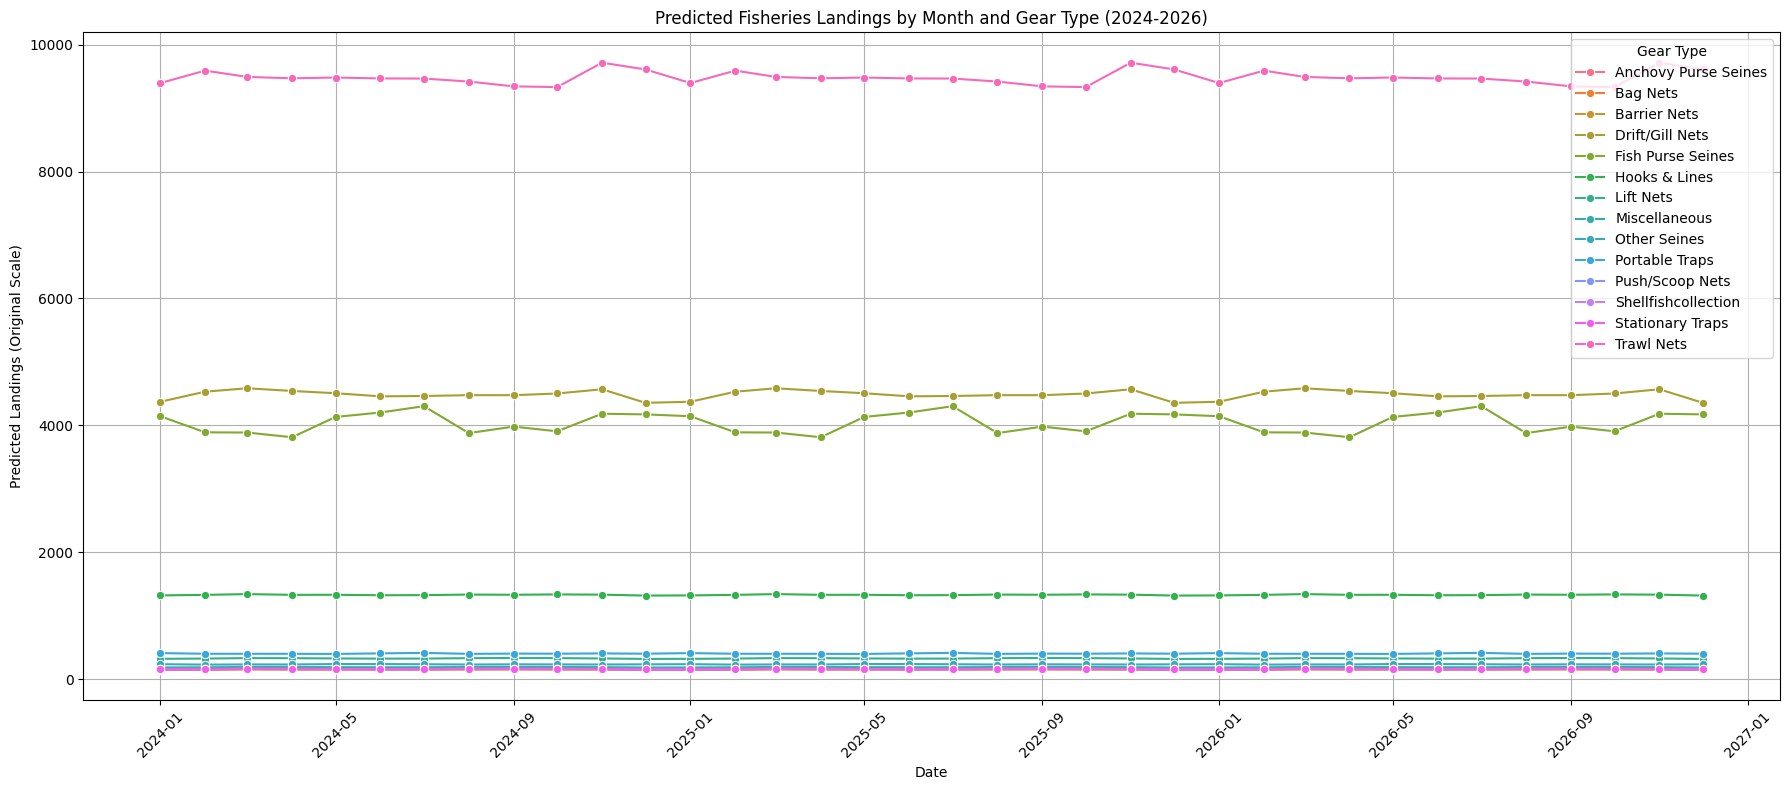

In [ ]:
# Aggregate forecasts by year, month, and gear type
if 'gear_type' in forecast_df_decoded.columns:
    print("\nVisualizing Forecasts By Gear Type...")

    monthly_gear_forecasts = forecast_df_decoded.groupby(['year', 'month', 'gear_type'])['predicted_landings'].sum().reset_index()

    # Convert year and month to a combined period for plotting
    monthly_gear_forecasts['period'] = pd.to_datetime(
        monthly_gear_forecasts['year'].astype(str) + '-' + monthly_gear_forecasts['month'].astype(str) + '-01'
    )
    monthly_gear_forecasts = monthly_gear_forecasts.sort_values(['gear_type', 'period'])

    # Get the list of unique gear types for plotting
    unique_gear_types = monthly_gear_forecasts['gear_type'].unique()

    # Plotting each gear type's forecast
    plt.figure(figsize=(18, 8)) # Adjust figure size

    # Use hue to plot different gear types as separate lines
    sns.lineplot(x='period', y='predicted_landings', hue='gear_type', data=monthly_gear_forecasts, marker='o')

    plt.title('Predicted Fisheries Landings by Month and Gear Type (2024-2026)')
    plt.xlabel('Date')
    plt.ylabel('Predicted Landings (Original Scale)')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.legend(title='Gear Type') # Add legend for gear type
    plt.tight_layout()
    plt.show()

else:
    print("\nDecoded 'gear_type' column not available. Cannot visualize forecasts by gear type.")

### 10.3.4 By State + Species + Gear Type

In [ ]:
# prompt: visualize By State + Gear Type  in timeline, one species one graph

# Aggregate forecasts by year, month, state, species, and gear type
if all(col in forecast_df_decoded.columns for col in ['state', 'species', 'gear_type']):
    print("\nVisualizing Forecasts By State, Species, and Gear Type...")

    # This combination might result in many unique groups.
    # Plotting all on one graph might be too cluttered.
    # Let's loop through each species and create a separate plot showing State + Gear Type for that species.

    unique_species_decoded = forecast_df_decoded['species'].unique()

    for species_name in unique_species_decoded:
        print(f"\nPlotting for Species: {species_name}")
        species_forecasts = forecast_df_decoded[forecast_df_decoded['species'] == species_name].copy()

        # Create a combined State + Gear Type column for plotting
        species_forecasts['state_gear_type'] = species_forecasts['state'] + ' (' + species_forecasts['gear_type'] + ')'

        # Aggregate for the specific species
        monthly_species_state_gear_forecasts = species_forecasts.groupby(['year', 'month', 'state_gear_type'])['predicted_landings'].sum().reset_index()

        # Convert year and month to a combined period for plotting
        monthly_species_state_gear_forecasts['period'] = pd.to_datetime(
            monthly_species_state_gear_forecasts['year'].astype(str) + '-' + monthly_species_state_gear_forecasts['month'].astype(str) + '-01'
        )
        monthly_species_state_gear_forecasts = monthly_species_state_gear_forecasts.sort_values(['state_gear_type', 'period'])

        # Plotting for this species
        plt.figure(figsize=(18, 8)) # Adjust figure size

        # Use hue for combined State + Gear Type
        sns.lineplot(x='period', y='predicted_landings', hue='state_gear_type', data=monthly_species_state_gear_forecasts, marker='o')

        plt.title(f'Predicted Fisheries Landings by Month and State + Gear Type for {species_name} (2024-2026)')
        plt.xlabel('Date')
        plt.ylabel('Predicted Landings (Original Scale)')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.legend(title='State + Gear Type', bbox_to_anchor=(1.05, 1), loc='upper left') # Add legend outside plot
        plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
        plt.show()

else:
    print("\nDecoded 'state', 'species', or 'gear_type' columns not available. Cannot visualize forecasts by State + Species + Gear Type.")
